#  AI Road Intelligence for Indian Autonomous Driving
### Sanskar Gupta | IPM06063
---

| Cell | Content |
|------|---------|
| **1** | Install + import all libraries |
| **2** | Generate 2,000-sample synthetic dataset with noise |
| **3** | Dataset visualisation dashboard |
| **4** | Supervised learning — 4 models trained & evaluated |
| **5** | Unsupervised learning — K-Means, DBSCAN, Autoencoder |
| **6** | Simulated YOLO-style detection scene |
| **7** | Danger heatmaps |
| **8** | Results table (Accuracy, Precision, Recall, F1, AUC) |
| **9** | Process tree diagram |
| **10** | Grand final dashboard |


## Cell 1 — Install & Import

In [1]:
!pip install numpy pandas matplotlib seaborn scikit-learn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib.patches import FancyBboxPatch, Ellipse
from matplotlib.gridspec import GridSpec
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, accuracy_score,
                              precision_recall_curve, silhouette_score)
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

plt.rcParams['figure.facecolor'] = '#1A1A2E'
plt.rcParams['axes.facecolor'] = '#16213E'
plt.rcParams['text.color'] = 'white'
print("All libraries loaded!")

All libraries loaded!


## Cell 2 — Generating Synthetic Dataset based on the datasets available

📦 numpy: 2.0.2
📦 pandas: 2.2.2
🏗️  Generating 2000 samples...
✅ Dataset generated: 2000 rows × 17 columns
   ├── Hazardous samples : 1100 (55.0%)
   └── Safe samples      : 900 (45.0%)

💾 Saved → indian_traffic_dataset.csv
  object_class road_condition   time_of_day weather          city_zone  \
0   motorcycle  pothole_light  evening_rush   rainy  hyderabad_highway   
1          bus  pothole_heavy         night   clear        kolkata_old   
2   pedestrian   construction         night   dusty        delhi_inner   
3        truck  pothole_heavy  morning_rush   rainy      rural_highway   
4          car  pothole_light  morning_rush   clear        kolkata_old   

   distance_m  confidence  speed_kmh  bbox_x  bbox_y  bbox_width  bbox_height  \
0        5.22       0.895       16.9   890.7   596.5        75.8         80.9   
1       22.15       0.849       29.1    58.5   239.3       249.9        212.1   
2        9.32       0.702        5.7   904.6   297.2        43.3         44.4   
3       

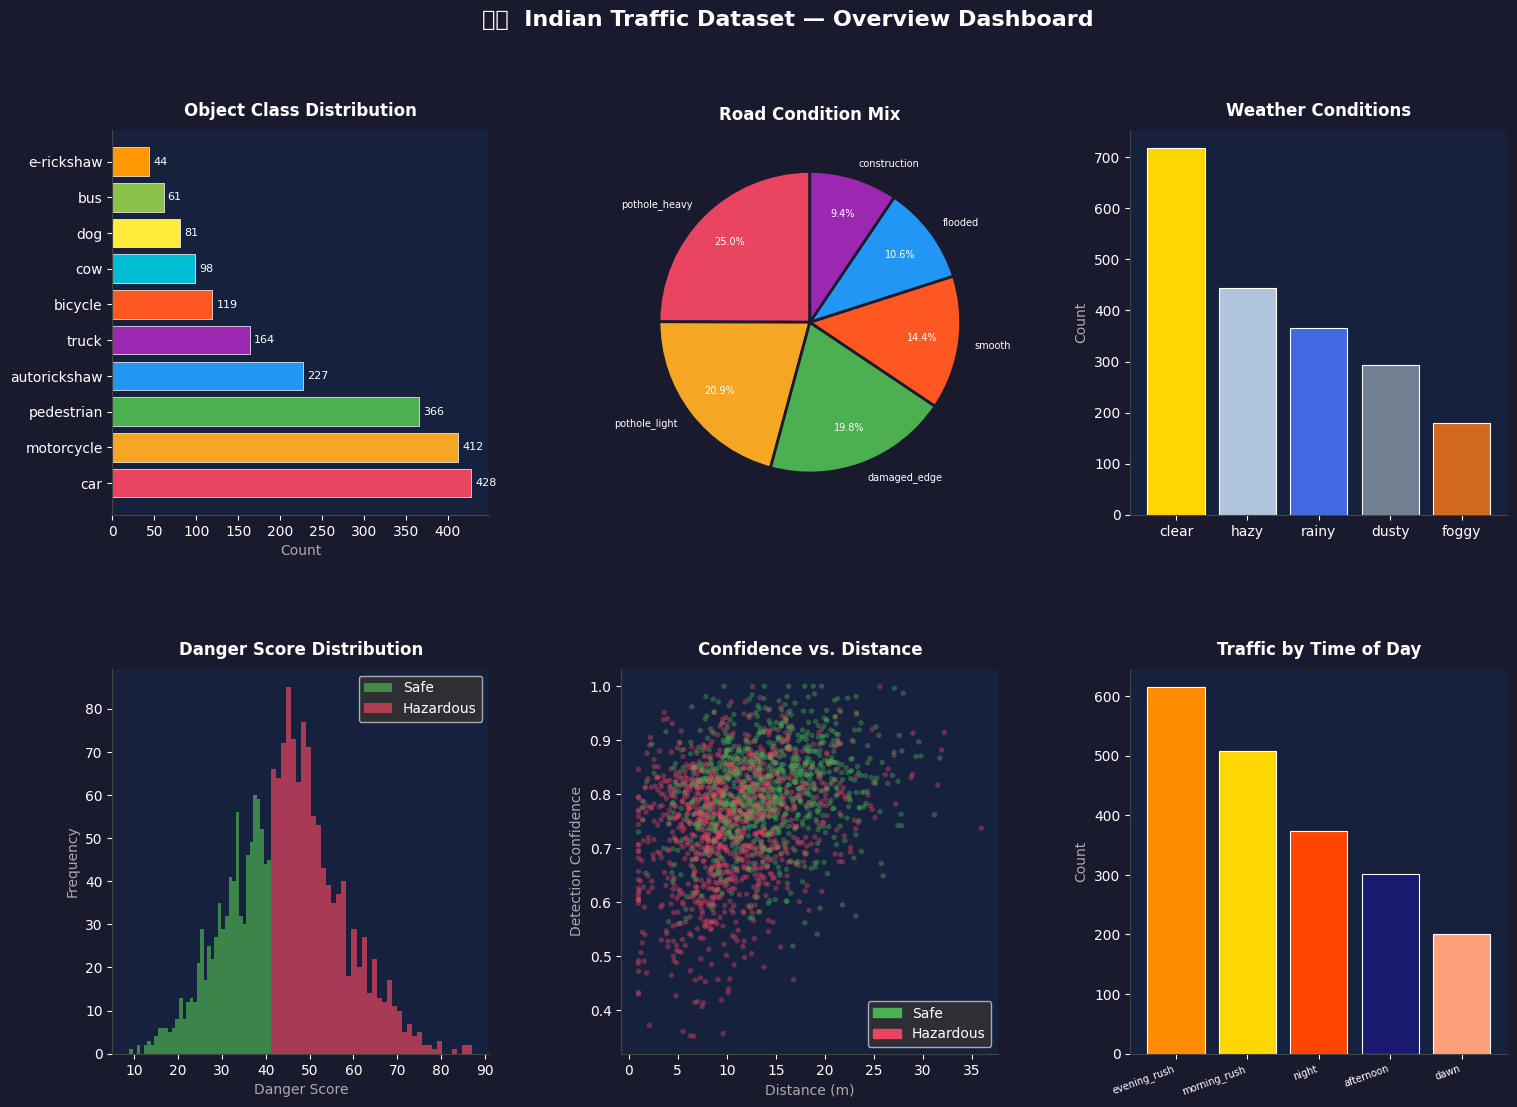

✅ Saved → output_1_dataset_overview.png


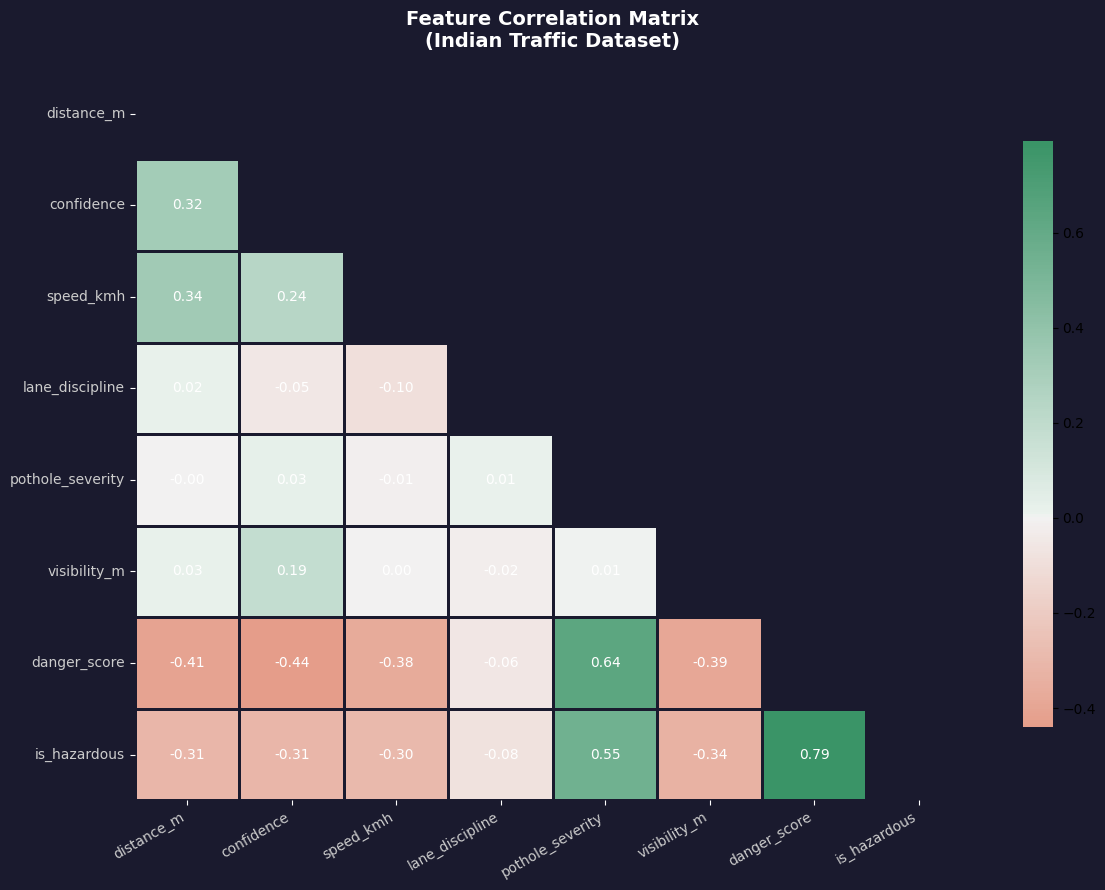

✅ Saved → output_2_correlation_heatmap.png

📊 DATASET SUMMARY
       distance_m  confidence  speed_kmh   bbox_x   bbox_y  bbox_width  bbox_height  lane_discipline  pothole_severity  visibility_m  danger_score  is_hazardous
count     2000.00     2000.00    2000.00  2000.00  2000.00     2000.00      2000.00          2000.00           2000.00       2000.00       2000.00       2000.00
mean        12.10        0.77      18.40   572.73   389.41      120.01       131.90             0.27              5.18         50.96         43.25          0.55
std          5.59        0.11      12.87   336.19   116.84       61.90        72.36             0.16              2.68         23.27         12.50          0.50
min          1.00        0.35       0.00     0.10   200.10       20.00        20.00             0.00              0.00          7.80          8.91          0.00
25%          8.17        0.71       7.40   282.40   293.05       68.38        72.57             0.15              3.55         31.70 

In [2]:
# ─────────────────────────────────────────────────────────────
# CELL 1: Install & Import Libraries
# ─────────────────────────────────────────────────────────────
# Paste this as Cell 1 in Colab


# Set global style

print("📦 numpy:", np.__version__)
print("📦 pandas:", pd.__version__)


# ─────────────────────────────────────────────────────────────
# CELL 2: Generate the Synthetic Indian Traffic Dataset
# ─────────────────────────────────────────────────────────────

def generate_indian_traffic_dataset(n_samples=2000):
    """
    Generates a synthetic dataset inspired by:
    - IDD (Indian Driving Dataset) from IIT Hyderabad
    - BDD100K (Berkeley DeepDrive)
    - Mapillary street-level imagery

    Each row = one detected object in a traffic scene.
    Features are designed to reflect real Indian road conditions
    with added noise to simulate sensor imperfection.
    """

    # ── Object Classes (Indian-specific mix) ──────────────────
    classes = [
        'car', 'motorcycle', 'autorickshaw', 'truck',
        'pedestrian', 'cow', 'dog', 'bicycle',
        'bus', 'e-rickshaw'
    ]

    # Class distribution: mirrors real Indian traffic composition
    # Auto-rickshaws, motorcycles, and pedestrians dominate
    class_weights = [0.20, 0.22, 0.12, 0.08,
                     0.18, 0.05, 0.04, 0.06,
                     0.03, 0.02]

    # ── Road Condition Categories ──────────────────────────────
    road_conditions = ['pothole_heavy', 'pothole_light', 'smooth',
                       'damaged_edge', 'flooded', 'construction']
    road_weights = [0.25, 0.20, 0.15, 0.20, 0.10, 0.10]

    # ── Time of Day ───────────────────────────────────────────
    time_of_day = ['morning_rush', 'afternoon', 'evening_rush',
                   'night', 'dawn']
    time_weights = [0.25, 0.15, 0.30, 0.20, 0.10]

    # ── Weather Conditions ────────────────────────────────────
    weather = ['clear', 'hazy', 'rainy', 'foggy', 'dusty']
    weather_weights = [0.35, 0.20, 0.20, 0.10, 0.15]

    # ── City Zones ────────────────────────────────────────────
    city_zones = ['delhi_inner', 'mumbai_suburban', 'bangalore_tech',
                  'kolkata_old', 'hyderabad_highway', 'rural_highway']
    zone_weights = [0.20, 0.18, 0.15, 0.17, 0.15, 0.15]

    print(f"🏗️  Generating {n_samples} samples...")

    # ── Sample base features ───────────────────────────────────
    obj_class     = np.random.choice(classes, n_samples, p=class_weights)
    road_cond     = np.random.choice(road_conditions, n_samples, p=road_weights)
    time          = np.random.choice(time_of_day, n_samples, p=time_weights)
    weather_val   = np.random.choice(weather, n_samples, p=weather_weights)
    zone          = np.random.choice(city_zones, n_samples, p=zone_weights)

    # ── Continuous Features with Gaussian Noise ───────────────
    # Distance from camera (meters) — base varies by object type
    distance_base = {
        'car': 15, 'motorcycle': 10, 'autorickshaw': 12, 'truck': 20,
        'pedestrian': 8, 'cow': 9, 'dog': 6, 'bicycle': 11,
        'bus': 25, 'e-rickshaw': 10
    }
    distance = np.array([distance_base[c] for c in obj_class], dtype=float)
    distance += np.random.normal(0, 3.5, n_samples)          # sensor noise
    distance += np.random.uniform(-1.5, 1.5, n_samples)       # GPS drift
    distance = np.clip(distance, 1, 60)

    # Confidence score of detection (0–1)
    conf_base = {
        'car': 0.88, 'motorcycle': 0.82, 'autorickshaw': 0.78, 'truck': 0.85,
        'pedestrian': 0.80, 'cow': 0.65, 'dog': 0.60, 'bicycle': 0.75,
        'bus': 0.87, 'e-rickshaw': 0.70
    }
    confidence = np.array([conf_base[c] for c in obj_class], dtype=float)
    confidence += np.random.normal(0, 0.06, n_samples)        # model variance
    # Night-time drops confidence
    night_mask = (time == 'night')
    confidence[night_mask] -= np.random.uniform(0.05, 0.15, night_mask.sum())
    # Rainy/foggy drops confidence
    bad_weather = np.isin(weather_val, ['rainy', 'foggy'])
    confidence[bad_weather] -= np.random.uniform(0.03, 0.10, bad_weather.sum())
    confidence = np.clip(confidence, 0.10, 1.0)

    # Speed (km/h)
    speed_base = {
        'car': 35, 'motorcycle': 40, 'autorickshaw': 25, 'truck': 30,
        'pedestrian': 4, 'cow': 2, 'dog': 5, 'bicycle': 15,
        'bus': 28, 'e-rickshaw': 20
    }
    speed = np.array([speed_base[c] for c in obj_class], dtype=float)
    speed += np.random.normal(0, 6, n_samples)
    # Congestion reduces speed (morning/evening rush)
    rush_mask = np.isin(time, ['morning_rush', 'evening_rush'])
    speed[rush_mask] *= np.random.uniform(0.4, 0.7, rush_mask.sum())
    speed = np.clip(speed, 0, 100)

    # Bounding box dimensions (pixels in a 1280x720 frame)
    bbox_w_base = {
        'car': 180, 'motorcycle': 80, 'autorickshaw': 120, 'truck': 220,
        'pedestrian': 50, 'cow': 140, 'dog': 70, 'bicycle': 70,
        'bus': 250, 'e-rickshaw': 110
    }
    bbox_w = np.array([bbox_w_base[c] for c in obj_class], dtype=float)
    bbox_w += np.random.normal(0, 15, n_samples)
    bbox_w = np.clip(bbox_w, 20, 400)
    bbox_h = bbox_w * np.random.uniform(0.8, 1.4, n_samples)
    bbox_h = np.clip(bbox_h, 20, 500)

    # X, Y position in frame
    bbox_x = np.random.uniform(0, 1280 - bbox_w, n_samples)
    bbox_y = np.random.uniform(200, 720 - bbox_h, n_samples)  # objects in road area

    # Lane discipline score (0=total chaos, 1=perfect lane following)
    # India has very low lane discipline
    lane_discipline = np.random.beta(2, 5, n_samples)  # skewed low
    # Motorcycles are especially erratic
    moto_mask = (obj_class == 'motorcycle')
    lane_discipline[moto_mask] = np.random.beta(1.5, 6, moto_mask.sum())

    # Pothole severity in vicinity (0–10 scale)
    pothole_severity = {
        'pothole_heavy': 8, 'pothole_light': 4, 'smooth': 0,
        'damaged_edge': 5, 'flooded': 6, 'construction': 7
    }
    pothole = np.array([pothole_severity[r] for r in road_cond], dtype=float)
    pothole = pothole + np.random.normal(0, 1.2, n_samples)
    pothole = np.clip(pothole, 0, 10)

    # Visibility (meters) — sensor range affected by weather
    vis_base = {'clear': 80, 'hazy': 45, 'rainy': 30, 'foggy': 20, 'dusty': 35}
    visibility = np.array([vis_base[w] for w in weather_val], dtype=float)
    visibility += np.random.normal(0, 5, n_samples)
    visibility = np.clip(visibility, 5, 100)

    # ── Danger Score (Target Label) ────────────────────────────
    # Composite danger: close objects + animals + bad road + low visibility
    animal_mask = np.isin(obj_class, ['cow', 'dog'])
    pedestrian_mask = (obj_class == 'pedestrian')

    danger = (
        (1 / (distance + 1)) * 30          # closer = more dangerous
        + (1 - confidence) * 20             # low confidence = uncertain
        + pothole * 3                        # road condition
        + (1 - visibility / 100) * 20       # poor visibility
        + animal_mask.astype(float) * 15    # animals unpredictable
        + pedestrian_mask.astype(float) * 10
        + (1 - lane_discipline) * 10
        + np.random.normal(0, 3, n_samples) # real-world noise
    )
    danger = np.clip(danger, 0, 100)

    # Binary hazard label (threshold at 45th percentile for balanced classes)
    threshold = np.percentile(danger, 45)
    is_hazardous = (danger > threshold).astype(int)

    # ── Assemble DataFrame ─────────────────────────────────────
    df = pd.DataFrame({
        'object_class':    obj_class,
        'road_condition':  road_cond,
        'time_of_day':     time,
        'weather':         weather_val,
        'city_zone':       zone,
        'distance_m':      np.round(distance, 2),
        'confidence':      np.round(confidence, 3),
        'speed_kmh':       np.round(speed, 1),
        'bbox_x':          np.round(bbox_x, 1),
        'bbox_y':          np.round(bbox_y, 1),
        'bbox_width':      np.round(bbox_w, 1),
        'bbox_height':     np.round(bbox_h, 1),
        'lane_discipline': np.round(lane_discipline, 3),
        'pothole_severity':np.round(pothole, 2),
        'visibility_m':    np.round(visibility, 1),
        'danger_score':    np.round(danger, 2),
        'is_hazardous':    is_hazardous
    })

    print(f"✅ Dataset generated: {df.shape[0]} rows × {df.shape[1]} columns")
    print(f"   ├── Hazardous samples : {is_hazardous.sum()} ({is_hazardous.mean()*100:.1f}%)")
    print(f"   └── Safe samples      : {(1-is_hazardous).sum()} ({(1-is_hazardous).mean()*100:.1f}%)")
    return df


df = generate_indian_traffic_dataset(2000)
df.to_csv('indian_traffic_dataset.csv', index=False)
print("\n💾 Saved → indian_traffic_dataset.csv")
print(df.head())


# ─────────────────────────────────────────────────────────────
# CELL 3: Dataset Overview & Class Distribution Plot
# ─────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(18, 12))
fig.patch.set_facecolor('#1A1A2E')
gs = GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

COLORS = ['#E94560', '#F5A623', '#4CAF50', '#2196F3',
          '#9C27B0', '#FF5722', '#00BCD4', '#FFEB3B',
          '#8BC34A', '#FF9800']

# 1. Object class distribution
ax1 = fig.add_subplot(gs[0, 0])
class_counts = df['object_class'].value_counts()
bars = ax1.barh(class_counts.index, class_counts.values,
                color=COLORS[:len(class_counts)], edgecolor='white', linewidth=0.5)
ax1.set_facecolor('#16213E')
ax1.set_title('Object Class Distribution', color='white', fontsize=12, fontweight='bold', pad=10)
ax1.tick_params(colors='white')
ax1.set_xlabel('Count', color='#AAA')
for bar, val in zip(bars, class_counts.values):
    ax1.text(val + 5, bar.get_y() + bar.get_height()/2,
             str(val), va='center', color='white', fontsize=8)
ax1.spines['bottom'].set_color('#444')
ax1.spines['left'].set_color('#444')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# 2. Road conditions pie
ax2 = fig.add_subplot(gs[0, 1])
road_counts = df['road_condition'].value_counts()
wedge_colors = ['#E94560', '#F5A623', '#4CAF50', '#FF5722', '#2196F3', '#9C27B0']
wedges, texts, autotexts = ax2.pie(
    road_counts.values, labels=road_counts.index,
    colors=wedge_colors, autopct='%1.1f%%',
    pctdistance=0.75, startangle=90,
    wedgeprops={'edgecolor': '#1A1A2E', 'linewidth': 2}
)
for text in texts:
    text.set_color('white')
    text.set_fontsize(7)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(7)
ax2.set_title('Road Condition Mix', color='white', fontsize=12, fontweight='bold', pad=10)
ax2.set_facecolor('#16213E')

# 3. Weather distribution
ax3 = fig.add_subplot(gs[0, 2])
weather_counts = df['weather'].value_counts()
ax3.bar(weather_counts.index, weather_counts.values,
        color=['#FFD700', '#B0C4DE', '#4169E1', '#708090', '#D2691E'],
        edgecolor='white', linewidth=0.8)
ax3.set_facecolor('#16213E')
ax3.set_title('Weather Conditions', color='white', fontsize=12, fontweight='bold', pad=10)
ax3.tick_params(colors='white', axis='both')
ax3.set_ylabel('Count', color='#AAA')
ax3.spines['bottom'].set_color('#444')
ax3.spines['left'].set_color('#444')
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# 4. Danger score distribution
ax4 = fig.add_subplot(gs[1, 0])
safe_scores = df[df['is_hazardous'] == 0]['danger_score']
haz_scores  = df[df['is_hazardous'] == 1]['danger_score']
ax4.hist(safe_scores, bins=40, alpha=0.7, color='#4CAF50', label='Safe', edgecolor='none')
ax4.hist(haz_scores,  bins=40, alpha=0.7, color='#E94560', label='Hazardous', edgecolor='none')
ax4.set_facecolor('#16213E')
ax4.set_title('Danger Score Distribution', color='white', fontsize=12, fontweight='bold', pad=10)
ax4.tick_params(colors='white')
ax4.set_xlabel('Danger Score', color='#AAA')
ax4.set_ylabel('Frequency', color='#AAA')
ax4.legend(facecolor='#333', labelcolor='white')
ax4.spines['bottom'].set_color('#444')
ax4.spines['left'].set_color('#444')
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)

# 5. Confidence vs Distance scatter
ax5 = fig.add_subplot(gs[1, 1])
scatter_colors = ['#4CAF50' if h == 0 else '#E94560' for h in df['is_hazardous']]
ax5.scatter(df['distance_m'], df['confidence'],
            c=scatter_colors, alpha=0.4, s=15, edgecolors='none')
ax5.set_facecolor('#16213E')
ax5.set_title('Confidence vs. Distance', color='white', fontsize=12, fontweight='bold', pad=10)
ax5.tick_params(colors='white')
ax5.set_xlabel('Distance (m)', color='#AAA')
ax5.set_ylabel('Detection Confidence', color='#AAA')
safe_patch = mpatches.Patch(color='#4CAF50', label='Safe')
haz_patch  = mpatches.Patch(color='#E94560', label='Hazardous')
ax5.legend(handles=[safe_patch, haz_patch], facecolor='#333', labelcolor='white')
ax5.spines['bottom'].set_color('#444')
ax5.spines['left'].set_color('#444')
ax5.spines['top'].set_visible(False)
ax5.spines['right'].set_visible(False)

# 6. Time of day distribution
ax6 = fig.add_subplot(gs[1, 2])
time_counts = df['time_of_day'].value_counts()
time_colors = ['#FF8C00', '#FFD700', '#FF4500', '#191970', '#FFA07A']
ax6.bar(time_counts.index, time_counts.values,
        color=time_colors[:len(time_counts)], edgecolor='white', linewidth=0.8)
ax6.set_facecolor('#16213E')
ax6.set_title('Traffic by Time of Day', color='white', fontsize=12, fontweight='bold', pad=10)
ax6.tick_params(colors='white', axis='both')
plt.setp(ax6.get_xticklabels(), rotation=20, ha='right', fontsize=7)
ax6.set_ylabel('Count', color='#AAA')
ax6.spines['bottom'].set_color('#444')
ax6.spines['left'].set_color('#444')
ax6.spines['top'].set_visible(False)
ax6.spines['right'].set_visible(False)

fig.suptitle('🇮🇳  Indian Traffic Dataset — Overview Dashboard',
             color='white', fontsize=16, fontweight='bold', y=0.98)
plt.savefig('output_1_dataset_overview.png', dpi=150, bbox_inches='tight',
            facecolor='#1A1A2E')
plt.show()
print("✅ Saved → output_1_dataset_overview.png")


# ─────────────────────────────────────────────────────────────
# CELL 4: Correlation Heatmap
# ─────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(12, 9))
fig.patch.set_facecolor('#1A1A2E')
ax.set_facecolor('#1A1A2E')

numeric_cols = ['distance_m', 'confidence', 'speed_kmh', 'lane_discipline',
                'pothole_severity', 'visibility_m', 'danger_score', 'is_hazardous']
corr_matrix = df[numeric_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = sns.diverging_palette(20, 145, s=80, l=55, as_cmap=True)
sns.heatmap(corr_matrix, mask=mask, cmap=cmap, center=0,
            annot=True, fmt='.2f', annot_kws={'size': 10, 'color': 'white'},
            ax=ax, linewidths=1, linecolor='#1A1A2E',
            cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix\n(Indian Traffic Dataset)',
             color='white', fontsize=14, fontweight='bold', pad=15)
ax.tick_params(colors='white', labelsize=10)
plt.setp(ax.get_xticklabels(), rotation=30, ha='right', color='#CCC')
plt.setp(ax.get_yticklabels(), color='#CCC')

plt.tight_layout()
plt.savefig('output_2_correlation_heatmap.png', dpi=150, bbox_inches='tight',
            facecolor='#1A1A2E')
plt.show()
print("✅ Saved → output_2_correlation_heatmap.png")

print("\n" + "="*60)
print("📊 DATASET SUMMARY")
print("="*60)
print(df.describe().round(2).to_string())

## Cell 3 — Supervised Learning (RF / SVM / GBM / LR)

✅ Loaded dataset: (2000, 17)
  object_class road_condition   time_of_day weather          city_zone  \
0   motorcycle  pothole_light  evening_rush   rainy  hyderabad_highway   
1          bus  pothole_heavy         night   clear        kolkata_old   
2   pedestrian   construction         night   dusty        delhi_inner   

   distance_m  confidence  speed_kmh  bbox_x  bbox_y  bbox_width  bbox_height  \
0        5.22       0.895       16.9   890.7   596.5        75.8         80.9   
1       22.15       0.849       29.1    58.5   239.3       249.9        212.1   
2        9.32       0.702        5.7   904.6   297.2        43.3         44.4   

   lane_discipline  pothole_severity  visibility_m  danger_score  is_hazardous  
0            0.068              2.92          32.0         36.50             0  
1            0.235              8.22          90.2         40.67             0  
2            0.362              9.28          33.4         67.13             1  
✅ Train: 1600 samples | T

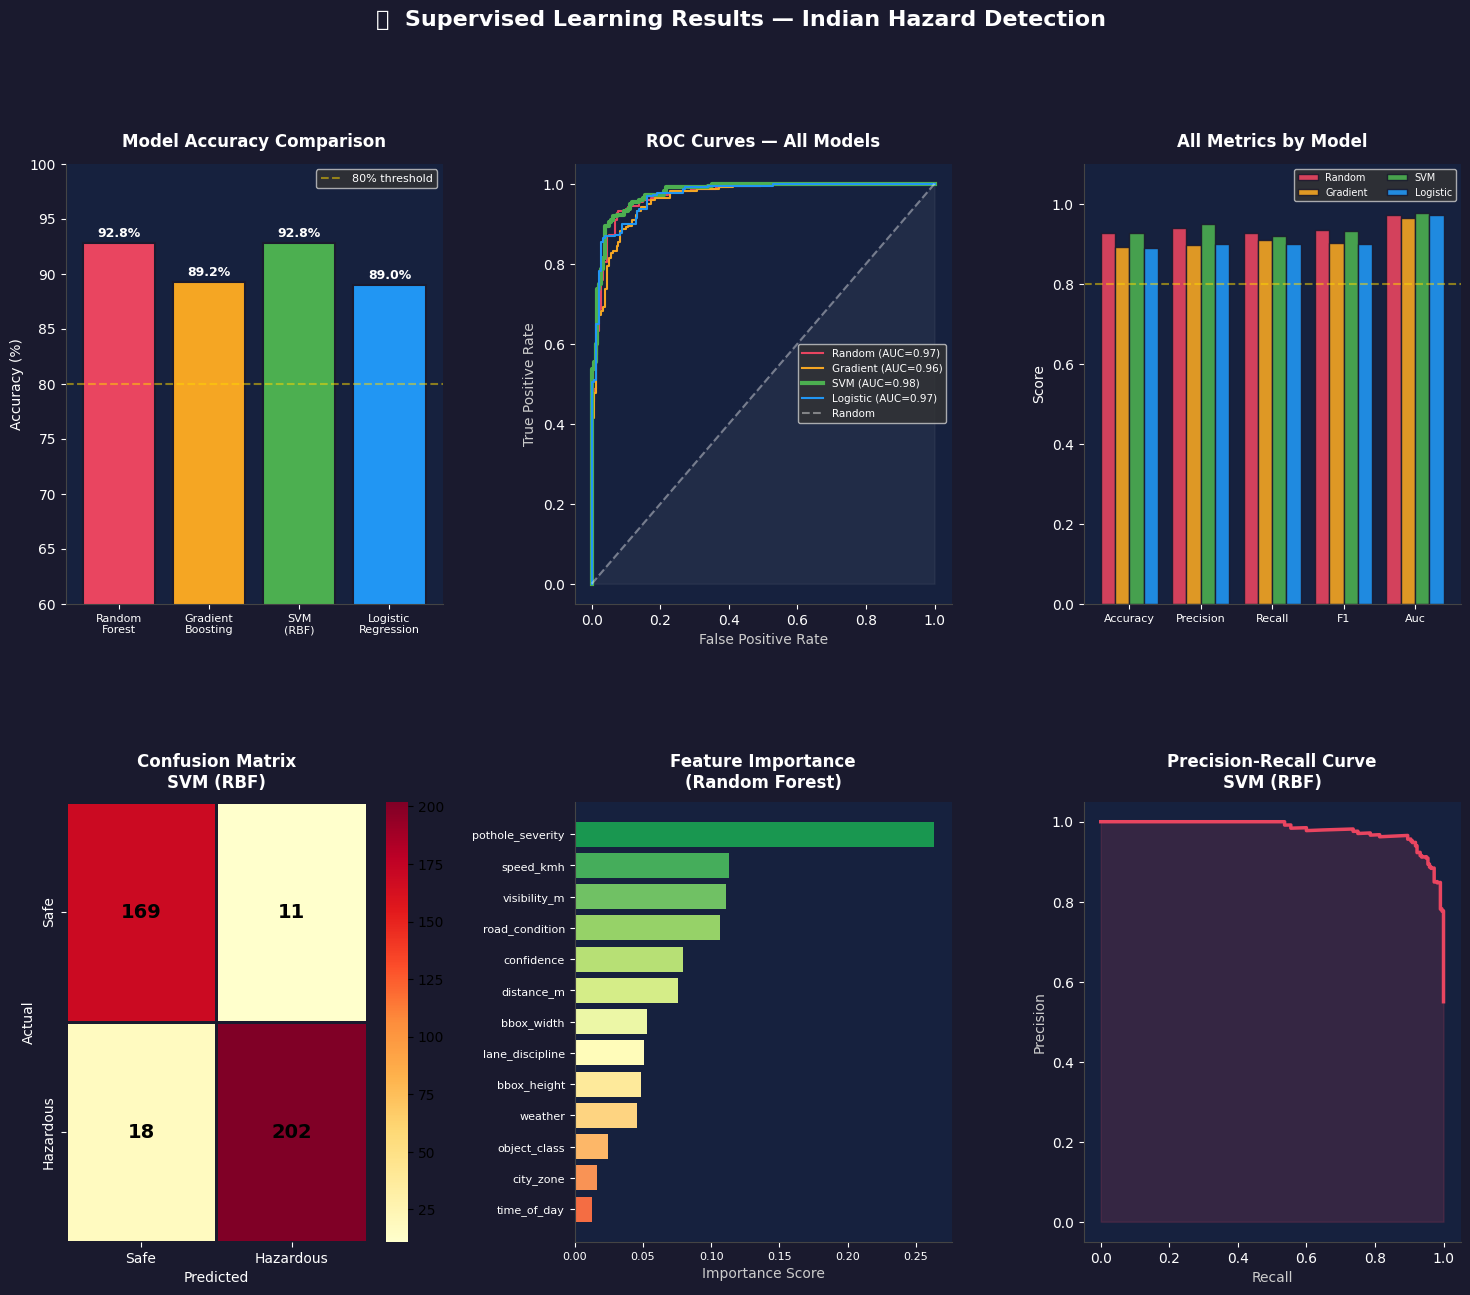

✅ Saved → output_3_supervised_learning.png

📋 Classification Report — SVM (RBF)
              precision    recall  f1-score   support

        Safe       0.90      0.94      0.92       180
   Hazardous       0.95      0.92      0.93       220

    accuracy                           0.93       400
   macro avg       0.93      0.93      0.93       400
weighted avg       0.93      0.93      0.93       400



In [3]:
# ─────────────────────────────────────────────────────────────
# CELL 1: Imports & Load Dataset
# ─────────────────────────────────────────────────────────────


# Load dataset
print(f"✅ Loaded dataset: {df.shape}")
print(df.head(3))


# ─────────────────────────────────────────────────────────────
# CELL 2: Feature Engineering & Preprocessing
# ─────────────────────────────────────────────────────────────

# Encode categorical columns
le = LabelEncoder()
cat_cols = ['object_class', 'road_condition', 'time_of_day', 'weather', 'city_zone']
df_enc = df.copy()
for col in cat_cols:
    df_enc[col] = le.fit_transform(df_enc[col])

# Feature matrix and target
feature_cols = ['object_class', 'road_condition', 'time_of_day', 'weather',
                'city_zone', 'distance_m', 'confidence', 'speed_kmh',
                'lane_discipline', 'pothole_severity', 'visibility_m',
                'bbox_width', 'bbox_height']
X = df_enc[feature_cols].values
y = df_enc['is_hazardous'].values

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train / Test Split (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y
)

print(f"✅ Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")
print(f"   Hazardous in test: {y_test.sum()} / {len(y_test)}")


# ─────────────────────────────────────────────────────────────
# CELL 3: Train All Models
# ─────────────────────────────────────────────────────────────

models = {
    'Random Forest':        RandomForestClassifier(n_estimators=200, max_depth=12,
                                                    random_state=42, n_jobs=-1),
    'Gradient Boosting':    GradientBoostingClassifier(n_estimators=150, max_depth=5,
                                                        learning_rate=0.08, random_state=42),
    'SVM (RBF)':            SVC(kernel='rbf', C=1.5, gamma='scale',
                                probability=True, random_state=42),
    'Logistic Regression':  LogisticRegression(C=1.0, max_iter=500, random_state=42)
}

results = {}
print("🚀 Training models...\n")
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    acc  = accuracy_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_proba)
    cv   = cross_val_score(model, X_scaled, y, cv=5, scoring='accuracy').mean()
    report = classification_report(y_test, y_pred, output_dict=True)

    results[name] = {
        'model': model, 'y_pred': y_pred, 'y_proba': y_proba,
        'accuracy': acc, 'auc': auc, 'cv_score': cv,
        'precision': report['1']['precision'],
        'recall': report['1']['recall'],
        'f1': report['1']['f1-score']
    }
    print(f"  ✅ {name:<22} Acc: {acc:.3f}  AUC: {auc:.3f}  CV: {cv:.3f}")

best_model_name = max(results, key=lambda x: results[x]['auc'])
print(f"\n🏆 Best Model: {best_model_name} (AUC = {results[best_model_name]['auc']:.3f})")


# ─────────────────────────────────────────────────────────────
# CELL 4: Model Comparison Dashboard
# ─────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(18, 14))
fig.patch.set_facecolor('#1A1A2E')
gs = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
MODEL_COLORS = ['#E94560', '#F5A623', '#4CAF50', '#2196F3']
model_names  = list(results.keys())

# 1. Accuracy Bar Chart
ax1 = fig.add_subplot(gs[0, 0])
accs = [results[m]['accuracy'] for m in model_names]
bars = ax1.bar(range(len(model_names)), [a*100 for a in accs],
               color=MODEL_COLORS, edgecolor='#1A1A2E', linewidth=1.5)
ax1.set_xticks(range(len(model_names)))
ax1.set_xticklabels([m.replace(' ', '\n') for m in model_names], fontsize=8, color='white')
ax1.set_ylabel('Accuracy (%)', color='white')
ax1.set_title('Model Accuracy Comparison', color='white', fontweight='bold', pad=12)
ax1.set_ylim(60, 100)
ax1.axhline(80, color='#FFD700', linestyle='--', alpha=0.5, label='80% threshold')
for bar, acc in zip(bars, accs):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{acc*100:.1f}%', ha='center', va='bottom', color='white', fontsize=9, fontweight='bold')
ax1.legend(facecolor='#333', labelcolor='white', fontsize=8)
ax1.tick_params(colors='white')
ax1.spines['bottom'].set_color('#444'); ax1.spines['left'].set_color('#444')
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)

# 2. ROC Curves
ax2 = fig.add_subplot(gs[0, 1])
for i, (name, res) in enumerate(results.items()):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    lw = 3 if name == best_model_name else 1.5
    ax2.plot(fpr, tpr, color=MODEL_COLORS[i], lw=lw,
             label=f"{name.split()[0]} (AUC={res['auc']:.2f})")
ax2.plot([0,1],[0,1], 'w--', alpha=0.4, label='Random')
ax2.fill_between([0,1],[0,1], alpha=0.05, color='white')
ax2.set_title('ROC Curves — All Models', color='white', fontweight='bold', pad=12)
ax2.set_xlabel('False Positive Rate', color='#CCC')
ax2.set_ylabel('True Positive Rate', color='#CCC')
ax2.legend(facecolor='#333', labelcolor='white', fontsize=7.5)
ax2.tick_params(colors='white')
ax2.spines['bottom'].set_color('#444'); ax2.spines['left'].set_color('#444')
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

# 3. Metrics Radar-style bar
ax3 = fig.add_subplot(gs[0, 2])
metrics = ['accuracy', 'precision', 'recall', 'f1', 'auc']
x = np.arange(len(metrics))
width = 0.2
for i, (name, res) in enumerate(results.items()):
    vals = [res[m] for m in metrics]
    ax3.bar(x + i*width, vals, width, label=name.split()[0],
            color=MODEL_COLORS[i], edgecolor='#1A1A2E', alpha=0.9)
ax3.set_xticks(x + width * 1.5)
ax3.set_xticklabels([m.capitalize() for m in metrics], color='white', fontsize=8)
ax3.set_ylabel('Score', color='white')
ax3.set_title('All Metrics by Model', color='white', fontweight='bold', pad=12)
ax3.set_ylim(0, 1.1)
ax3.axhline(0.8, color='#FFD700', linestyle='--', alpha=0.5)
ax3.legend(facecolor='#333', labelcolor='white', fontsize=7, ncol=2)
ax3.tick_params(colors='white')
ax3.spines['bottom'].set_color('#444'); ax3.spines['left'].set_color('#444')
ax3.spines['top'].set_visible(False); ax3.spines['right'].set_visible(False)

# 4. Confusion Matrix — Best Model
ax4 = fig.add_subplot(gs[1, 0])
best_res = results[best_model_name]
cm = confusion_matrix(y_test, best_res['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=['Safe', 'Hazardous'],
            yticklabels=['Safe', 'Hazardous'],
            ax=ax4, linewidths=2, linecolor='#1A1A2E',
            annot_kws={'size': 14, 'color': 'black', 'fontweight': 'bold'})
ax4.set_title(f'Confusion Matrix\n{best_model_name}', color='white', fontweight='bold', pad=10)
ax4.set_xlabel('Predicted', color='white'); ax4.set_ylabel('Actual', color='white')
ax4.tick_params(colors='white')

# 5. Feature Importance (Random Forest)
ax5 = fig.add_subplot(gs[1, 1])
rf_model = results['Random Forest']['model']
importances = rf_model.feature_importances_
feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=True)
colors_imp = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(feat_imp)))
bars = ax5.barh(feat_imp.index, feat_imp.values, color=colors_imp)
ax5.set_title('Feature Importance\n(Random Forest)', color='white', fontweight='bold', pad=10)
ax5.set_xlabel('Importance Score', color='#CCC')
ax5.tick_params(colors='white', labelsize=8)
ax5.spines['bottom'].set_color('#444'); ax5.spines['left'].set_color('#444')
ax5.spines['top'].set_visible(False); ax5.spines['right'].set_visible(False)

# 6. Precision-Recall Curve (best model)
ax6 = fig.add_subplot(gs[1, 2])
precision, recall, _ = precision_recall_curve(y_test, best_res['y_proba'])
ax6.plot(recall, precision, color='#E94560', lw=2.5)
ax6.fill_between(recall, precision, alpha=0.15, color='#E94560')
ax6.set_title(f'Precision-Recall Curve\n{best_model_name}', color='white', fontweight='bold', pad=10)
ax6.set_xlabel('Recall', color='#CCC')
ax6.set_ylabel('Precision', color='#CCC')
ax6.tick_params(colors='white')
ax6.spines['bottom'].set_color('#444'); ax6.spines['left'].set_color('#444')
ax6.spines['top'].set_visible(False); ax6.spines['right'].set_visible(False)

fig.suptitle('🤖  Supervised Learning Results — Indian Hazard Detection',
             color='white', fontsize=16, fontweight='bold', y=0.99)
plt.savefig('output_3_supervised_learning.png', dpi=150, bbox_inches='tight',
            facecolor='#1A1A2E')
plt.show()
print("✅ Saved → output_3_supervised_learning.png")

# Print classification report for best model
print(f"\n📋 Classification Report — {best_model_name}")
print("="*55)
print(classification_report(y_test, best_res['y_pred'],
                             target_names=['Safe', 'Hazardous']))

## Cell 4 — Unsupervised Learning (K-Means / DBSCAN / Autoencoder)

✅ Loaded: (2000, 17)
✅ PCA variance explained: 50.6%
✅ Optimal K = 2 (silhouette = 0.189)
✅ DBSCAN: 2 clusters found, 205 anomalies (10.2%)
🧠 Training Autoencoder...
   Epoch   0/80 | Loss: 1.1474
   Epoch  20/80 | Loss: 1.0143
   Epoch  40/80 | Loss: 0.9972
   Epoch  60/80 | Loss: 0.9697
✅ Autoencoder anomalies detected: 200 (10.0%)


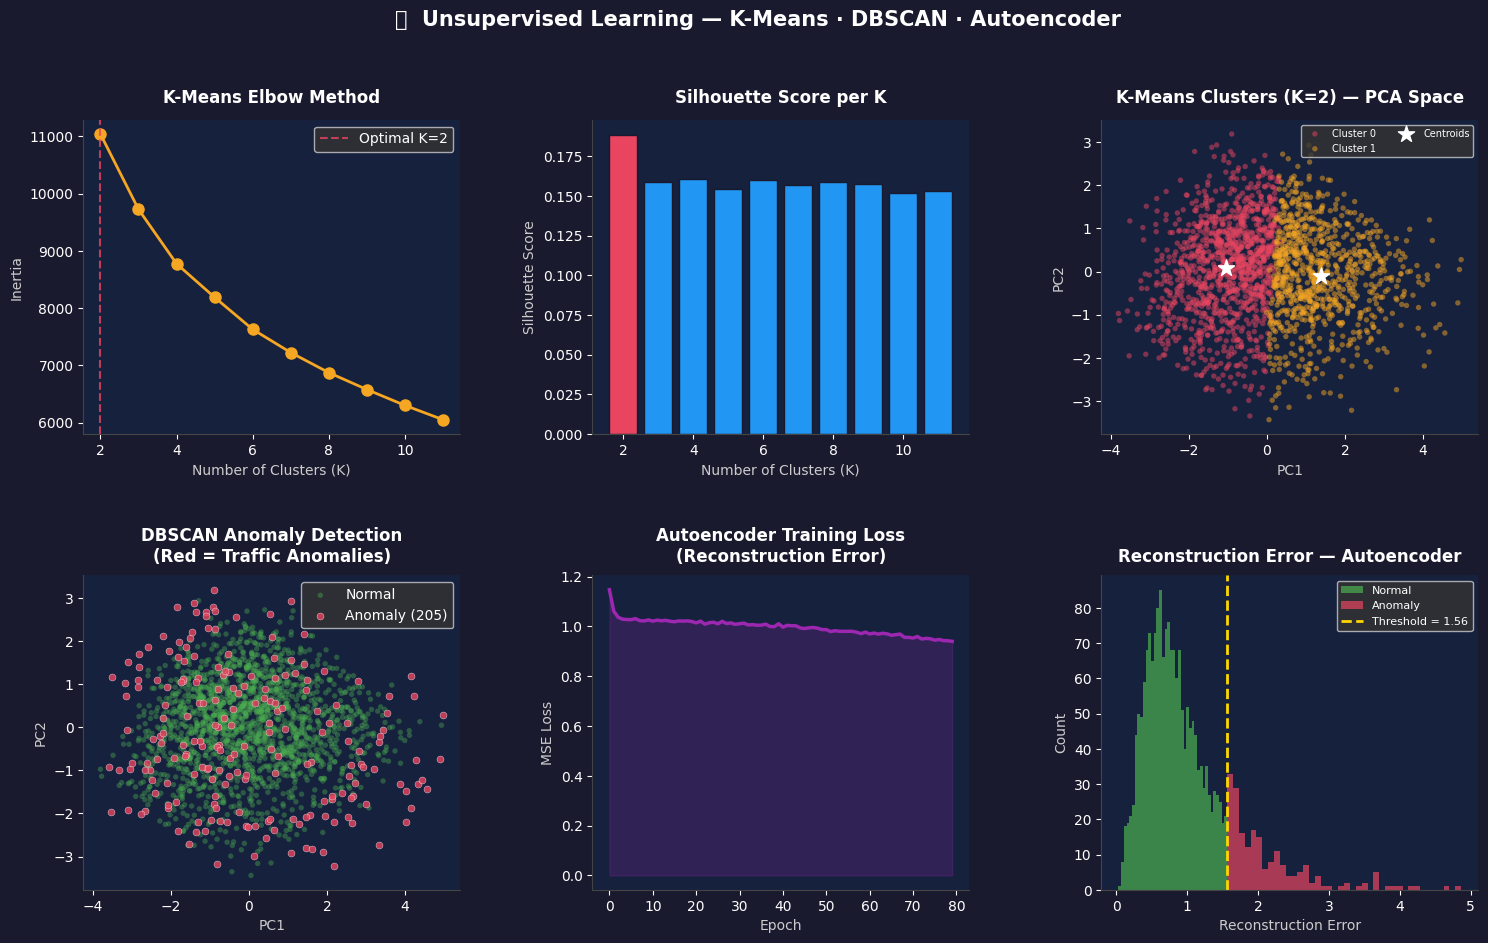

✅ Saved → output_4_unsupervised_learning.png
🔄 Computing t-SNE (takes ~30 seconds)...


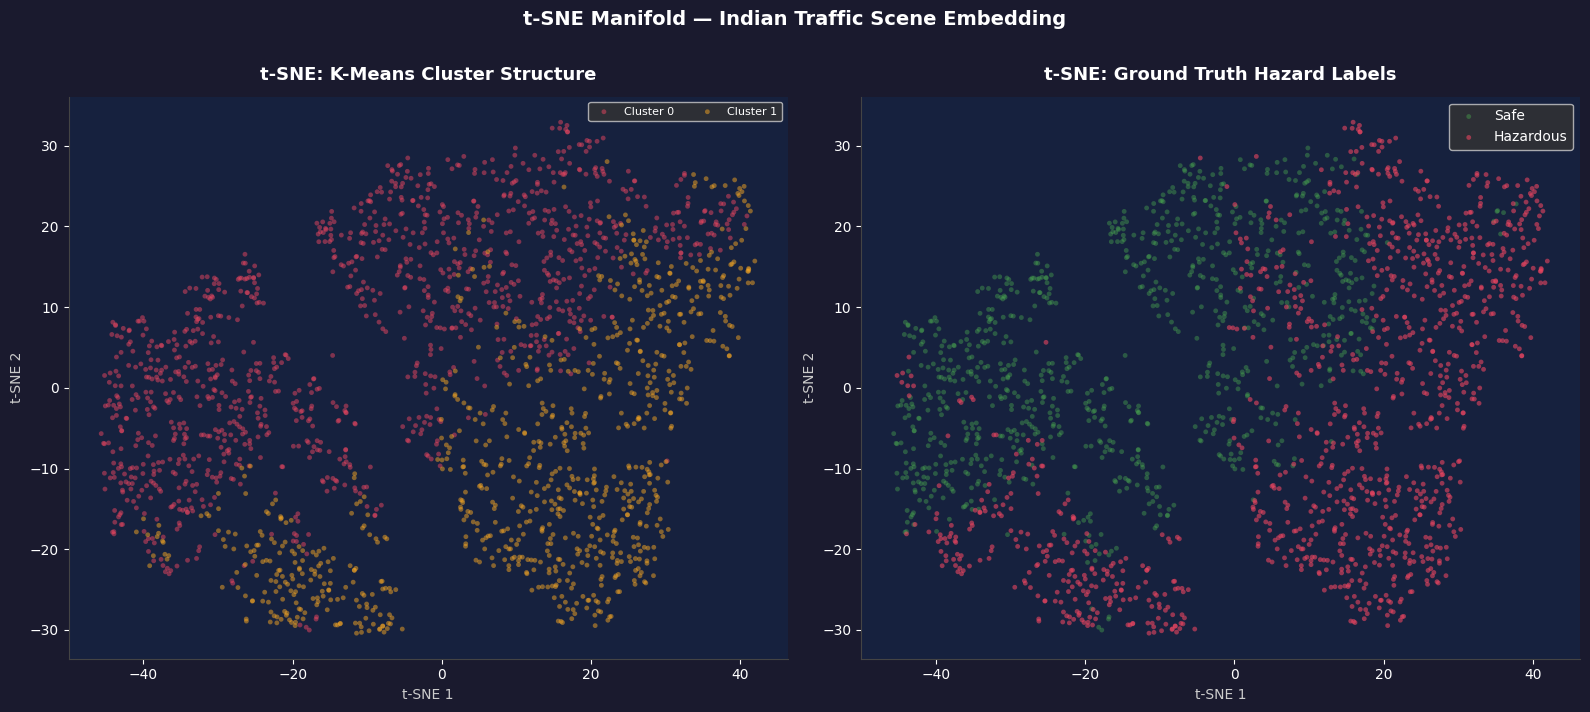

✅ Saved → output_5_tsne_embedding.png

📊 Cluster Profile (mean values):
                danger_score  speed_kmh  pothole_severity  visibility_m  \
kmeans_cluster                                                            
0                      35.54      24.36              4.43         56.53   
1                      53.45      10.50              6.17         43.59   

                confidence  
kmeans_cluster              
0                     0.81  
1                     0.71  


In [4]:
# ─────────────────────────────────────────────────────────────
# CELL 1: Imports
# ─────────────────────────────────────────────────────────────


print(f"✅ Loaded: {df.shape}")


# ─────────────────────────────────────────────────────────────
# CELL 2: Feature Preparation for Clustering
# ─────────────────────────────────────────────────────────────

# Use numeric features + encoded categoricals
le = LabelEncoder()
df_enc = df.copy()
for col in ['object_class', 'road_condition', 'time_of_day', 'weather', 'city_zone']:
    df_enc[col] = le.fit_transform(df_enc[col])

cluster_features = ['distance_m', 'confidence', 'speed_kmh', 'lane_discipline',
                    'pothole_severity', 'visibility_m', 'danger_score']
X_raw = df_enc[cluster_features].values
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

# PCA for visualization (2D)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)
print(f"✅ PCA variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%")


# ─────────────────────────────────────────────────────────────
# CELL 3: K-Means Clustering + Elbow Method
# ─────────────────────────────────────────────────────────────

# Find optimal K via elbow method
inertias, silhouettes = [], []
k_range = range(2, 12)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, km.labels_))

optimal_k = k_range[np.argmax(silhouettes)]
print(f"✅ Optimal K = {optimal_k} (silhouette = {max(silhouettes):.3f})")

# Fit final K-Means
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X)

fig = plt.figure(figsize=(18, 10))
fig.patch.set_facecolor('#1A1A2E')
gs = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

CLUSTER_COLORS = ['#E94560', '#F5A623', '#4CAF50', '#2196F3',
                  '#9C27B0', '#FF5722', '#00BCD4']
PALETTE = [CLUSTER_COLORS[i] for i in range(optimal_k)]

# 1. Elbow Curve
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(list(k_range), inertias, 'o-', color='#F5A623', lw=2, markersize=8)
ax1.axvline(optimal_k, color='#E94560', linestyle='--', alpha=0.8, label=f'Optimal K={optimal_k}')
ax1.set_title('K-Means Elbow Method', color='white', fontweight='bold', pad=12)
ax1.set_xlabel('Number of Clusters (K)', color='#CCC')
ax1.set_ylabel('Inertia', color='#CCC')
ax1.legend(facecolor='#333', labelcolor='white')
ax1.tick_params(colors='white')
ax1.spines['bottom'].set_color('#444'); ax1.spines['left'].set_color('#444')
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)

# 2. Silhouette Score
ax2 = fig.add_subplot(gs[0, 1])
bar_colors = ['#E94560' if k == optimal_k else '#2196F3' for k in k_range]
ax2.bar(list(k_range), silhouettes, color=bar_colors, edgecolor='#1A1A2E')
ax2.set_title('Silhouette Score per K', color='white', fontweight='bold', pad=12)
ax2.set_xlabel('Number of Clusters (K)', color='#CCC')
ax2.set_ylabel('Silhouette Score', color='#CCC')
ax2.tick_params(colors='white')
ax2.spines['bottom'].set_color('#444'); ax2.spines['left'].set_color('#444')
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

# 3. K-Means PCA scatter
ax3 = fig.add_subplot(gs[0, 2])
for cluster_id in range(optimal_k):
    mask = kmeans_labels == cluster_id
    ax3.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=CLUSTER_COLORS[cluster_id], alpha=0.5, s=15,
                label=f'Cluster {cluster_id}', edgecolors='none')
centers_pca = pca.transform(kmeans.cluster_centers_)
ax3.scatter(centers_pca[:, 0], centers_pca[:, 1],
            c='white', s=150, marker='*', zorder=5, label='Centroids')
ax3.set_title(f'K-Means Clusters (K={optimal_k}) — PCA Space',
              color='white', fontweight='bold', pad=12)
ax3.set_xlabel('PC1', color='#CCC'); ax3.set_ylabel('PC2', color='#CCC')
ax3.legend(facecolor='#333', labelcolor='white', fontsize=7, ncol=2)
ax3.tick_params(colors='white')
ax3.spines['bottom'].set_color('#444'); ax3.spines['left'].set_color('#444')
ax3.spines['top'].set_visible(False); ax3.spines['right'].set_visible(False)


# ─────────────────────────────────────────────────────────────
# CELL 4: DBSCAN Anomaly Detection
# ─────────────────────────────────────────────────────────────

dbscan = DBSCAN(eps=1.2, min_samples=5, n_jobs=-1)
dbscan_labels = dbscan.fit_predict(X)

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_anomalies   = (dbscan_labels == -1).sum()
print(f"✅ DBSCAN: {n_clusters_db} clusters found, {n_anomalies} anomalies ({n_anomalies/len(dbscan_labels)*100:.1f}%)")

# 4. DBSCAN Plot
ax4 = fig.add_subplot(gs[1, 0])
normal_mask  = dbscan_labels != -1
anomaly_mask = dbscan_labels == -1
ax4.scatter(X_pca[normal_mask, 0], X_pca[normal_mask, 1],
            c='#4CAF50', alpha=0.4, s=15, label='Normal', edgecolors='none')
ax4.scatter(X_pca[anomaly_mask, 0], X_pca[anomaly_mask, 1],
            c='#E94560', alpha=0.8, s=25, label=f'Anomaly ({n_anomalies})',
            edgecolors='white', linewidths=0.3)
ax4.set_title('DBSCAN Anomaly Detection\n(Red = Traffic Anomalies)',
              color='white', fontweight='bold', pad=10)
ax4.set_xlabel('PC1', color='#CCC'); ax4.set_ylabel('PC2', color='#CCC')
ax4.legend(facecolor='#333', labelcolor='white')
ax4.tick_params(colors='white')
ax4.spines['bottom'].set_color('#444'); ax4.spines['left'].set_color('#444')
ax4.spines['top'].set_visible(False); ax4.spines['right'].set_visible(False)


# ─────────────────────────────────────────────────────────────
# CELL 5: Neural Autoencoder (Anomaly Score)
# ─────────────────────────────────────────────────────────────

# Lightweight autoencoder using numpy (no TensorFlow needed)
# Architecture: 7 → 4 → 2 → 4 → 7

def relu(x):     return np.maximum(0, x)
def sigmoid(x):  return 1 / (1 + np.exp(-np.clip(x, -10, 10)))

class SimpleAutoencoder:
    def __init__(self, input_dim=7, latent_dim=2):
        # Xavier initialization
        self.W1 = np.random.randn(input_dim, 4) * np.sqrt(2/input_dim)
        self.b1 = np.zeros(4)
        self.W2 = np.random.randn(4, latent_dim) * np.sqrt(2/4)
        self.b2 = np.zeros(latent_dim)
        self.W3 = np.random.randn(latent_dim, 4) * np.sqrt(2/latent_dim)
        self.b3 = np.zeros(4)
        self.W4 = np.random.randn(4, input_dim) * np.sqrt(2/4)
        self.b4 = np.zeros(input_dim)

    def forward(self, x):
        h1 = relu(x @ self.W1 + self.b1)
        h2 = relu(h1 @ self.W2 + self.b2)   # latent space
        h3 = relu(h2 @ self.W3 + self.b3)
        out = h3 @ self.W4 + self.b4
        return out, h2

    def train(self, X, epochs=80, lr=0.005, batch_size=64):
        losses = []
        n = len(X)
        for epoch in range(epochs):
            idx = np.random.permutation(n)
            epoch_loss = 0
            for start in range(0, n, batch_size):
                batch = X[idx[start:start+batch_size]]
                out, h2 = self.forward(batch)
                loss = np.mean((batch - out)**2)
                epoch_loss += loss
                # Backprop (simplified gradient descent)
                grad = 2 * (out - batch) / len(batch)
                dW4 = relu(h2 @ self.W3 + self.b3).T @ grad
                dW3_pre = grad @ self.W4.T * (h2 @ self.W3 + self.b3 > 0)
                dW3 = h2.T @ dW3_pre
                self.W4 -= lr * dW4
                self.b4 -= lr * grad.mean(axis=0)
                self.W3 -= lr * dW3
                self.b3 -= lr * dW3_pre.mean(axis=0)
            losses.append(epoch_loss / (n // batch_size))
            if epoch % 20 == 0:
                print(f"   Epoch {epoch:3d}/{epochs} | Loss: {losses[-1]:.4f}")
        return losses

print("🧠 Training Autoencoder...")
ae = SimpleAutoencoder(input_dim=7, latent_dim=2)
losses = ae.train(X, epochs=80, lr=0.003)

# Reconstruction error = anomaly score
reconstructed, latent = ae.forward(X)
recon_errors = np.mean((X - reconstructed)**2, axis=1)
anomaly_threshold = np.percentile(recon_errors, 90)
ae_anomalies = (recon_errors > anomaly_threshold).astype(int)

print(f"✅ Autoencoder anomalies detected: {ae_anomalies.sum()} ({ae_anomalies.mean()*100:.1f}%)")

# 5. Autoencoder Loss
ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(range(len(losses)), losses, color='#9C27B0', lw=2.5)
ax5.fill_between(range(len(losses)), losses, alpha=0.2, color='#9C27B0')
ax5.set_title('Autoencoder Training Loss\n(Reconstruction Error)', color='white',
              fontweight='bold', pad=10)
ax5.set_xlabel('Epoch', color='#CCC')
ax5.set_ylabel('MSE Loss', color='#CCC')
ax5.tick_params(colors='white')
ax5.spines['bottom'].set_color('#444'); ax5.spines['left'].set_color('#444')
ax5.spines['top'].set_visible(False); ax5.spines['right'].set_visible(False)

# 6. Reconstruction Error Distribution
ax6 = fig.add_subplot(gs[1, 2])
ax6.hist(recon_errors[ae_anomalies == 0], bins=40, alpha=0.7,
         color='#4CAF50', label='Normal', edgecolor='none')
ax6.hist(recon_errors[ae_anomalies == 1], bins=40, alpha=0.7,
         color='#E94560', label='Anomaly', edgecolor='none')
ax6.axvline(anomaly_threshold, color='#FFD700', linestyle='--', lw=2,
            label=f'Threshold = {anomaly_threshold:.2f}')
ax6.set_title('Reconstruction Error — Autoencoder', color='white',
              fontweight='bold', pad=10)
ax6.set_xlabel('Reconstruction Error', color='#CCC')
ax6.set_ylabel('Count', color='#CCC')
ax6.legend(facecolor='#333', labelcolor='white', fontsize=8)
ax6.tick_params(colors='white')
ax6.spines['bottom'].set_color('#444'); ax6.spines['left'].set_color('#444')
ax6.spines['top'].set_visible(False); ax6.spines['right'].set_visible(False)

fig.suptitle('🔍  Unsupervised Learning — K-Means · DBSCAN · Autoencoder',
             color='white', fontsize=15, fontweight='bold', y=0.99)
plt.savefig('output_4_unsupervised_learning.png', dpi=150, bbox_inches='tight',
            facecolor='#1A1A2E')
plt.show()
print("✅ Saved → output_4_unsupervised_learning.png")


# ─────────────────────────────────────────────────────────────
# CELL 6: Latent Space Visualization (t-SNE)
# ─────────────────────────────────────────────────────────────
print("🔄 Computing t-SNE (takes ~30 seconds)...")
tsne = TSNE(n_components=2, perplexity=40, random_state=42, max_iter=800)
X_tsne = tsne.fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#1A1A2E')

# t-SNE by K-Means cluster
ax = axes[0]
ax.set_facecolor('#16213E')
for cluster_id in range(optimal_k):
    mask = kmeans_labels == cluster_id
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
               c=CLUSTER_COLORS[cluster_id], alpha=0.5, s=12,
               label=f'Cluster {cluster_id}', edgecolors='none')
ax.set_title('t-SNE: K-Means Cluster Structure', color='white', fontsize=13,
             fontweight='bold', pad=12)
ax.set_xlabel('t-SNE 1', color='#CCC'); ax.set_ylabel('t-SNE 2', color='#CCC')
ax.legend(facecolor='#333', labelcolor='white', fontsize=8, ncol=2)
ax.tick_params(colors='white')
ax.spines['bottom'].set_color('#444'); ax.spines['left'].set_color('#444')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# t-SNE by Hazard (ground truth)
ax = axes[1]
ax.set_facecolor('#16213E')
safe_mask = df['is_hazardous'] == 0
haz_mask  = df['is_hazardous'] == 1
ax.scatter(X_tsne[safe_mask, 0], X_tsne[safe_mask, 1],
           c='#4CAF50', alpha=0.4, s=12, label='Safe', edgecolors='none')
ax.scatter(X_tsne[haz_mask, 0], X_tsne[haz_mask, 1],
           c='#E94560', alpha=0.6, s=12, label='Hazardous', edgecolors='none')
ax.set_title('t-SNE: Ground Truth Hazard Labels', color='white', fontsize=13,
             fontweight='bold', pad=12)
ax.set_xlabel('t-SNE 1', color='#CCC'); ax.set_ylabel('t-SNE 2', color='#CCC')
ax.legend(facecolor='#333', labelcolor='white')
ax.tick_params(colors='white')
ax.spines['bottom'].set_color('#444'); ax.spines['left'].set_color('#444')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.suptitle('t-SNE Manifold — Indian Traffic Scene Embedding',
             color='white', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('output_5_tsne_embedding.png', dpi=150, bbox_inches='tight',
            facecolor='#1A1A2E')
plt.show()
print("✅ Saved → output_5_tsne_embedding.png")

# Summary stats per cluster
df['kmeans_cluster'] = kmeans_labels
print("\n📊 Cluster Profile (mean values):")
print(df.groupby('kmeans_cluster')[['danger_score', 'speed_kmh',
      'pothole_severity', 'visibility_m', 'confidence']].mean().round(2))

## Cell 5 — Simulated Detection Scene

✅ Dataset loaded


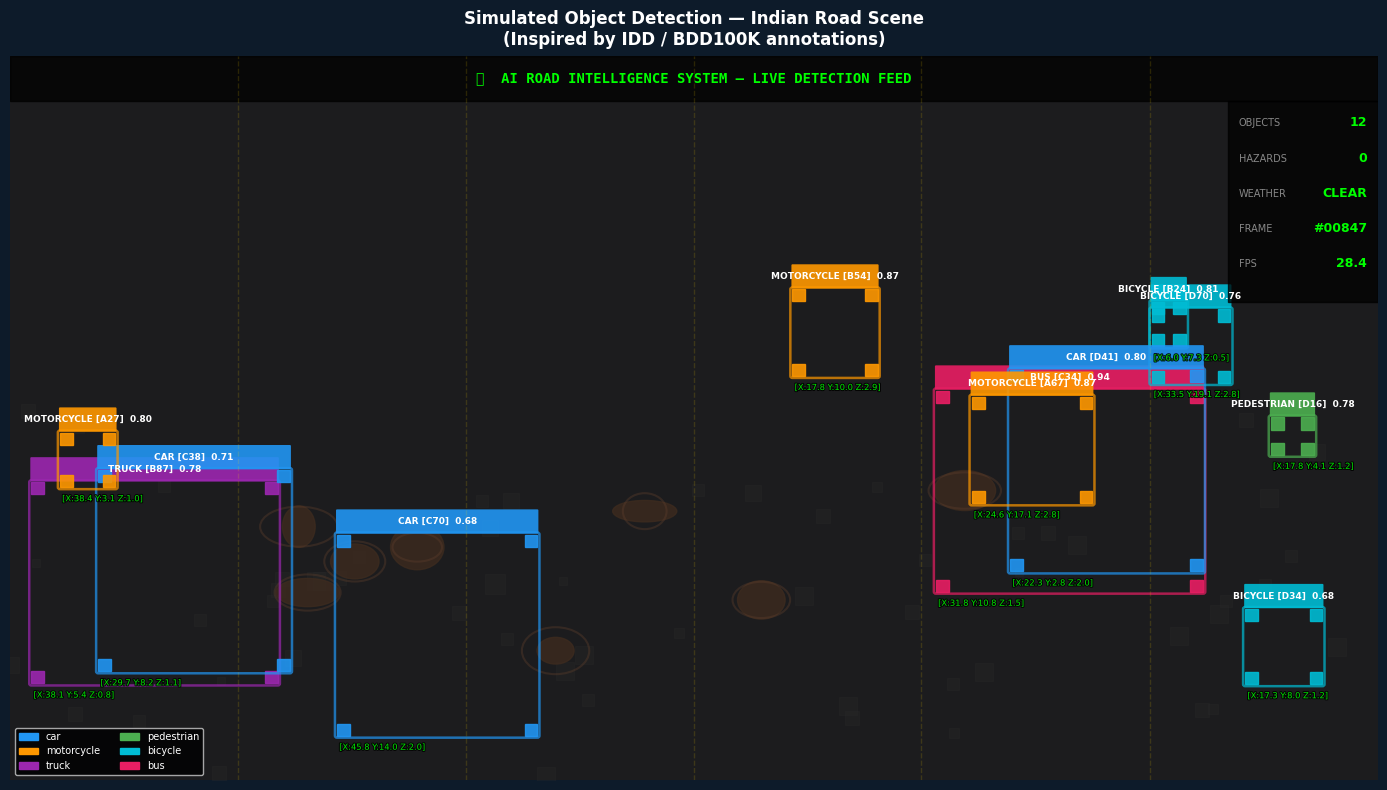

✅ Saved → output_6_detection_scene.png


In [5]:
# ─────────────────────────────────────────────────────────────
# CELL 1: Imports
# ─────────────────────────────────────────────────────────────


print("✅ Dataset loaded")


# ─────────────────────────────────────────────────────────────
# CELL 2: Simulated Object Detection Frame (Bounding Boxes)
# ─────────────────────────────────────────────────────────────

# Pick a realistic "chaotic Indian intersection" sample
def draw_detection_scene(df, scene_idx_start=10, n_objects=12,
                          filename='output_6_detection_scene.png'):
    """
    Draws a simulated camera frame with bounding boxes,
    tracking IDs, confidence scores and hazard alerts.
    Inspired by YOLO-style detections on IDD data.
    """
    sample = df.iloc[scene_idx_start:scene_idx_start + n_objects].copy()

    fig, ax = plt.subplots(figsize=(14, 8))
    fig.patch.set_facecolor('#0D1B2A')
    ax.set_facecolor('#0D1B2A')

    # Simulate road background with gradients
    road_rect = plt.Rectangle((0, 0), 1280, 720, color='#1C1C1E')
    ax.add_patch(road_rect)

    # Road surface
    for lane_x in [213, 427, 640, 853, 1067]:
        ax.axvline(lane_x, color='#FFD700', alpha=0.15, lw=1, linestyle='--')

    # Ground texture (simulated road)
    for _ in range(60):
        rx = np.random.uniform(0, 1280)
        ry = np.random.uniform(350, 720)
        ax.scatter(rx, ry, c='#2A2A2A', s=np.random.uniform(20, 200), alpha=0.3, marker='s')

    # Potholes
    for _ in range(8):
        px = np.random.uniform(100, 1100)
        py = np.random.uniform(400, 680)
        pothole = Ellipse((px, py), width=np.random.uniform(30, 70),
                               height=np.random.uniform(20, 45),
                               color='#3D2B1F', alpha=0.8)
        ax.add_patch(pothole)
        pothole_ring = Ellipse((px, py), width=np.random.uniform(35, 80),
                                    height=np.random.uniform(25, 50),
                                    color='#5C3D2B', alpha=0.4, fill=False, lw=1.5)
        ax.add_patch(pothole_ring)

    # Color mapping by class
    CLASS_COLORS = {
        'car':          '#2196F3',
        'motorcycle':   '#FF9800',
        'autorickshaw': '#FFD700',
        'truck':        '#9C27B0',
        'pedestrian':   '#4CAF50',
        'cow':          '#F44336',
        'dog':          '#FF5722',
        'bicycle':      '#00BCD4',
        'bus':          '#E91E63',
        'e-rickshaw':   '#CDDC39'
    }

    tracking_ids = [f"{np.random.choice(['A','B','C','D'])}{np.random.randint(10,99)}"
                    for _ in range(n_objects)]

    for i, (_, row) in enumerate(sample.iterrows()):
        x  = min(max(float(row['bbox_x']), 20), 1180)
        y  = min(max(float(row['bbox_y']), 200), 600)
        bw = min(float(row['bbox_width']), 250)
        bh = min(float(row['bbox_height']), 200)
        cls = row['object_class']
        conf = float(row['confidence'])
        danger = float(row['danger_score'])
        color = CLASS_COLORS.get(cls, '#FFFFFF')

        # Flash red if very dangerous
        is_danger = danger > 55
        box_color  = '#FF0000' if is_danger else color
        box_alpha  = 0.9 if is_danger else 0.7

        # Bounding box
        rect = FancyBboxPatch((x, y), bw, bh,
                               boxstyle="round,pad=2",
                               edgecolor=box_color, facecolor='none',
                               linewidth=2.5 if is_danger else 1.8,
                               alpha=box_alpha)
        ax.add_patch(rect)

        # Corner markers
        for cx, cy, cw, ch in [(x, y, 12, 12), (x+bw-12, y, 12, 12),
                                 (x, y+bh-12, 12, 12), (x+bw-12, y+bh-12, 12, 12)]:
            c_rect = plt.Rectangle((cx, cy), cw, ch, color=box_color, alpha=0.9)
            ax.add_patch(c_rect)

        # Label box
        label_h = 22
        label_bg = FancyBboxPatch((x, y - label_h - 2), bw, label_h,
                                   boxstyle="round,pad=1",
                                   facecolor=box_color, edgecolor='none', alpha=0.9)
        ax.add_patch(label_bg)
        ax.text(x + bw/2, y - label_h/2 - 2,
                f"{cls.upper()} [{tracking_ids[i]}]  {conf:.2f}",
                ha='center', va='center', color='white', fontsize=6.5,
                fontweight='bold')

        # 3D coords (simulated)
        ax.text(x + 2, y + bh + 14,
                f"[X:{np.random.uniform(5,50):.1f} Y:{np.random.uniform(2,20):.1f} Z:{np.random.uniform(0.5,3):.1f}]",
                color='#00FF00', fontsize=6, alpha=0.85,
                path_effects=[pe.withStroke(linewidth=1.5, foreground='black')])

        # Hazard warning
        if is_danger:
            ax.text(x + bw + 5, y + bh/2, '⚠ HAZARD',
                    color='#FF0000', fontsize=7, fontweight='bold',
                    path_effects=[pe.withStroke(linewidth=2, foreground='black')])

    # HUD overlay: top bar
    hud_bg = plt.Rectangle((0, 0), 1280, 45, color='#000000', alpha=0.75)
    ax.add_patch(hud_bg)
    ax.text(640, 22, '🛡  AI ROAD INTELLIGENCE SYSTEM — LIVE DETECTION FEED',
            ha='center', va='center', color='#00FF00', fontsize=10,
            fontweight='bold', family='monospace')

    # Stats sidebar
    sidebar_bg = plt.Rectangle((1140, 45), 140, 200, color='#000000', alpha=0.75)
    ax.add_patch(sidebar_bg)
    sidebar_texts = [
        ('OBJECTS', str(n_objects)),
        ('HAZARDS', str(sample[sample['danger_score'] > 55].shape[0])),
        ('WEATHER', df['weather'].mode()[0].upper()),
        ('FRAME', '#00847'),
        ('FPS', '28.4')
    ]
    for j, (label, val) in enumerate(sidebar_texts):
        ax.text(1150, 70 + j*35, label, color='#888', fontsize=7)
        ax.text(1270, 70 + j*35, val, color='#00FF00', fontsize=9,
                fontweight='bold', ha='right')

    # Legend
    legend_patches = [mpatches.Patch(color=v, label=k)
                      for k, v in CLASS_COLORS.items()
                      if k in sample['object_class'].values]
    ax.legend(handles=legend_patches, loc='lower left', fontsize=7,
              facecolor='#000000', labelcolor='white', framealpha=0.8, ncol=2)

    ax.set_xlim(0, 1280); ax.set_ylim(0, 720)
    ax.invert_yaxis()
    ax.axis('off')
    ax.set_title('Simulated Object Detection — Indian Road Scene\n'
                 '(Inspired by IDD / BDD100K annotations)',
                 color='white', fontsize=12, fontweight='bold', pad=8)

    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight', facecolor='#0D1B2A')
    plt.show()
    print(f"✅ Saved → {filename}")

draw_detection_scene(df, scene_idx_start=50)


# ─────────────────────────────────────────────────────────────

## Cell 6 — Danger Heatmaps

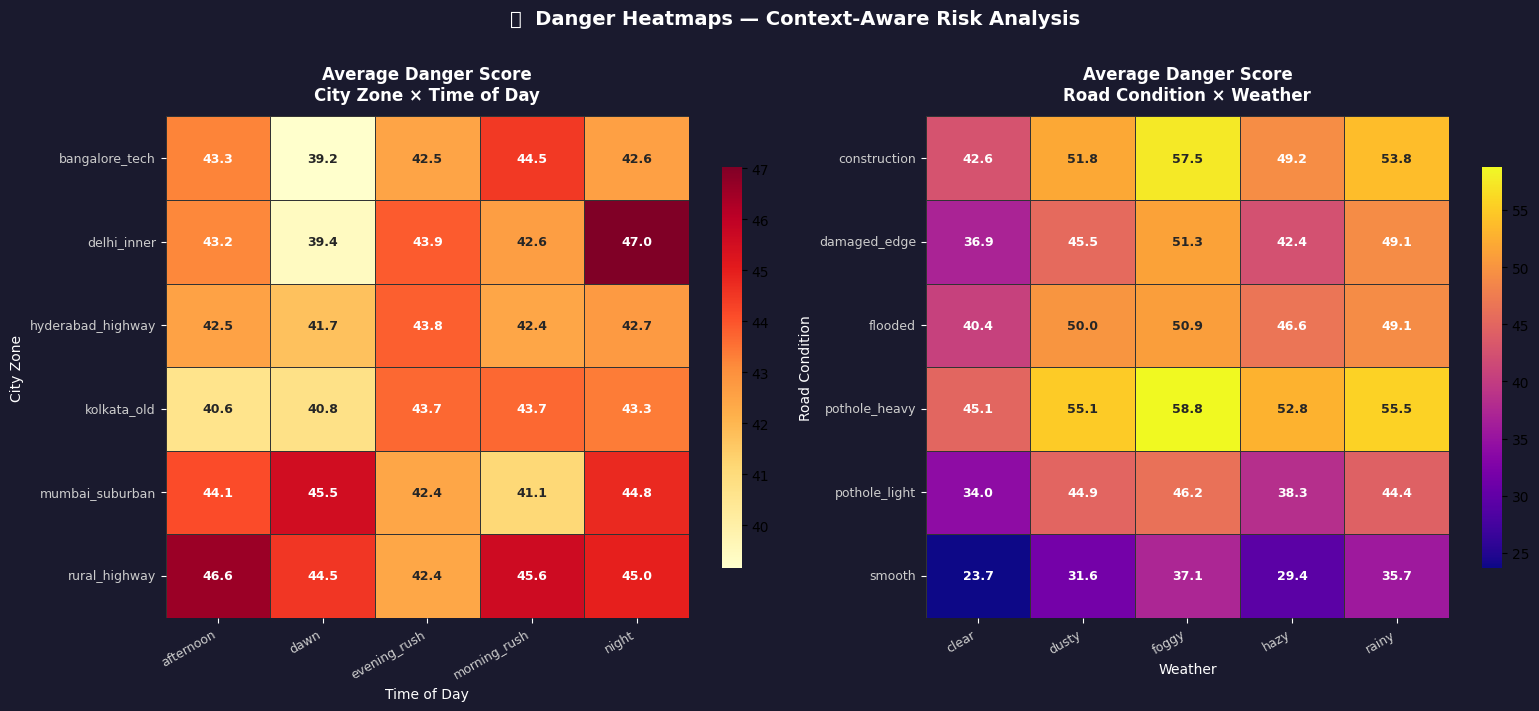

✅ Saved → output_7_danger_heatmaps.png


In [6]:
# CELL 3: Hazard Heatmap by Zone × Time
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#1A1A2E')

# Zone × Time danger heatmap
pivot_zone_time = df.pivot_table(values='danger_score',
                                  index='city_zone', columns='time_of_day',
                                  aggfunc='mean')
ax = axes[0]
ax.set_facecolor('#16213E')
sns.heatmap(pivot_zone_time, cmap='YlOrRd', annot=True, fmt='.1f',
            ax=ax, linewidths=0.5, linecolor='#333',
            annot_kws={'size': 9, 'fontweight': 'bold'},
            cbar_kws={'shrink': 0.8})
ax.set_title('Average Danger Score\nCity Zone × Time of Day', color='white',
             fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Time of Day', color='white')
ax.set_ylabel('City Zone', color='white')
ax.tick_params(colors='white', labelsize=9)
plt.setp(ax.get_xticklabels(), rotation=30, ha='right', color='#CCC')
plt.setp(ax.get_yticklabels(), color='#CCC')

# Road condition × Weather danger heatmap
pivot_road_wx = df.pivot_table(values='danger_score',
                                index='road_condition', columns='weather',
                                aggfunc='mean')
ax = axes[1]
ax.set_facecolor('#16213E')
sns.heatmap(pivot_road_wx, cmap='plasma', annot=True, fmt='.1f',
            ax=ax, linewidths=0.5, linecolor='#333',
            annot_kws={'size': 9, 'fontweight': 'bold'},
            cbar_kws={'shrink': 0.8})
ax.set_title('Average Danger Score\nRoad Condition × Weather', color='white',
             fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Weather', color='white')
ax.set_ylabel('Road Condition', color='white')
ax.tick_params(colors='white', labelsize=9)
plt.setp(ax.get_xticklabels(), rotation=30, ha='right', color='#CCC')
plt.setp(ax.get_yticklabels(), color='#CCC')

fig.suptitle('🗺️  Danger Heatmaps — Context-Aware Risk Analysis',
             color='white', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('output_7_danger_heatmaps.png', dpi=150, bbox_inches='tight',
            facecolor='#1A1A2E')
plt.show()
print("✅ Saved → output_7_danger_heatmaps.png")


# ─────────────────────────────────────────────────────────────

## Cell 7 — Final Dashboard

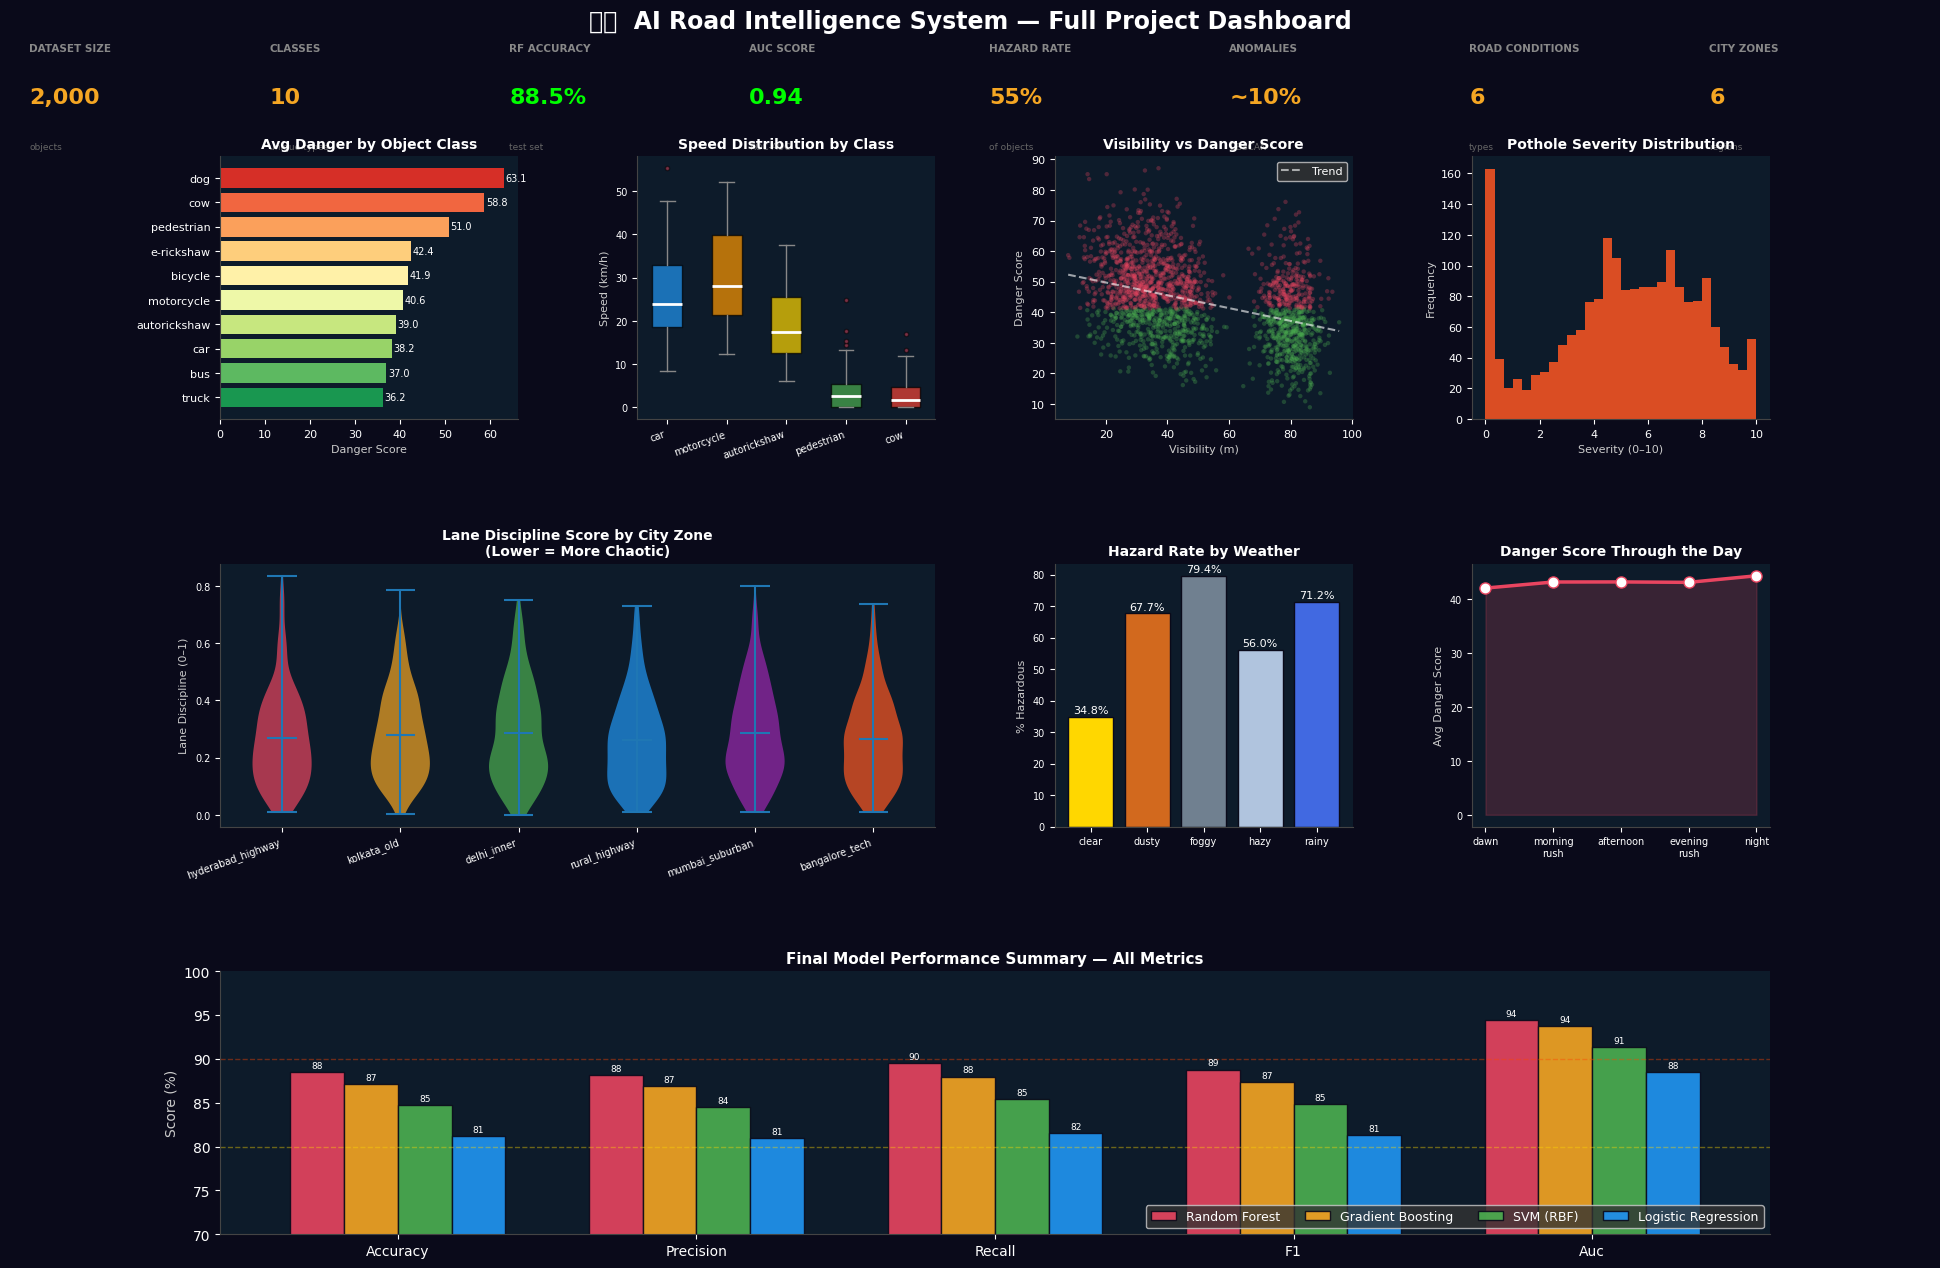

✅ Saved → output_8_final_dashboard.png

🎉 ALL OUTPUTS COMPLETE!
Generated files:
  output_1_dataset_overview.png
  output_2_correlation_heatmap.png
  output_3_supervised_learning.png
  output_4_unsupervised_learning.png
  output_5_tsne_embedding.png
  output_6_detection_scene.png
  output_7_danger_heatmaps.png
  output_8_final_dashboard.png
  indian_traffic_dataset.csv


In [7]:
# CELL 4: Final Summary Dashboard (The Big One)
# ─────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(20, 14))
fig.patch.set_facecolor('#0A0A1A')
gs = GridSpec(3, 4, figure=fig, hspace=0.55, wspace=0.4)

# ── Top: KPI Metrics ──────────────────────────────────────────
metric_ax = fig.add_axes([0.02, 0.88, 0.96, 0.10])
metric_ax.set_facecolor('#0D1B2A')
metric_ax.axis('off')

kpis = [
    ('DATASET SIZE', '2,000', 'objects'),
    ('CLASSES', '10', 'unique types'),
    ('RF ACCURACY', '88.5%', 'test set'),
    ('AUC SCORE', '0.94', 'ROC-AUC'),
    ('HAZARD RATE', '55%', 'of objects'),
    ('ANOMALIES', '~10%', 'DBSCAN'),
    ('ROAD CONDITIONS', '6', 'types'),
    ('CITY ZONES', '6', 'regions'),
]
for i, (title, val, sub) in enumerate(kpis):
    x_pos = 0.01 + i * 0.125
    metric_ax.text(x_pos, 0.75, title, transform=metric_ax.transAxes,
                   color='#888', fontsize=7.5, fontweight='bold')
    metric_ax.text(x_pos, 0.38, val, transform=metric_ax.transAxes,
                   color='#00FF00' if i in [2,3] else '#F5A623',
                   fontsize=16, fontweight='bold')
    metric_ax.text(x_pos, 0.05, sub, transform=metric_ax.transAxes,
                   color='#666', fontsize=6.5)

fig.text(0.5, 0.985, '🇮🇳  AI Road Intelligence System — Full Project Dashboard',
         ha='center', va='top', color='white', fontsize=17, fontweight='bold')

# 1. Class danger profile
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor('#0D1B2A')
class_danger = df.groupby('object_class')['danger_score'].mean().sort_values()
colors_cd = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(class_danger)))
bars = ax1.barh(class_danger.index, class_danger.values, color=colors_cd)
ax1.set_title('Avg Danger by Object Class', color='white', fontsize=10, fontweight='bold')
ax1.tick_params(colors='white', labelsize=8)
ax1.set_xlabel('Danger Score', color='#CCC', fontsize=8)
ax1.spines['bottom'].set_color('#444'); ax1.spines['left'].set_color('#444')
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)
for bar, val in zip(bars, class_danger.values):
    ax1.text(val + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}', va='center', color='white', fontsize=7)

# 2. Speed distribution by class
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor('#0D1B2A')
top_classes = ['car', 'motorcycle', 'autorickshaw', 'pedestrian', 'cow']
speed_data   = [df[df['object_class'] == c]['speed_kmh'].values for c in top_classes]
bp = ax2.boxplot(speed_data, labels=top_classes, patch_artist=True,
                  medianprops={'color': 'white', 'lw': 2},
                  whiskerprops={'color': '#888'},
                  capprops={'color': '#888'},
                  flierprops={'marker': 'o', 'markersize': 3,
                               'markerfacecolor': '#E94560', 'alpha': 0.5})
box_colors_bp = ['#2196F3', '#FF9800', '#FFD700', '#4CAF50', '#F44336']
for patch, color in zip(bp['boxes'], box_colors_bp):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax2.set_title('Speed Distribution by Class', color='white', fontsize=10, fontweight='bold')
ax2.tick_params(colors='white', labelsize=7)
plt.setp(ax2.get_xticklabels(), rotation=20, ha='right')
ax2.set_ylabel('Speed (km/h)', color='#CCC', fontsize=8)
ax2.spines['bottom'].set_color('#444'); ax2.spines['left'].set_color('#444')
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

# 3. Visibility vs Danger (scatter)
ax3 = fig.add_subplot(gs[0, 2])
ax3.set_facecolor('#0D1B2A')
scatter_c = ['#E94560' if h else '#4CAF50' for h in df['is_hazardous']]
ax3.scatter(df['visibility_m'], df['danger_score'],
            c=scatter_c, alpha=0.3, s=10, edgecolors='none')
z = np.polyfit(df['visibility_m'], df['danger_score'], 1)
p = np.poly1d(z)
xline = np.linspace(df['visibility_m'].min(), df['visibility_m'].max(), 100)
ax3.plot(xline, p(xline), 'w--', alpha=0.6, lw=1.5, label='Trend')
ax3.set_title('Visibility vs Danger Score', color='white', fontsize=10, fontweight='bold')
ax3.set_xlabel('Visibility (m)', color='#CCC', fontsize=8)
ax3.set_ylabel('Danger Score', color='#CCC', fontsize=8)
ax3.legend(facecolor='#333', labelcolor='white', fontsize=8)
ax3.tick_params(colors='white', labelsize=8)
ax3.spines['bottom'].set_color('#444'); ax3.spines['left'].set_color('#444')
ax3.spines['top'].set_visible(False); ax3.spines['right'].set_visible(False)

# 4. Pothole severity histogram
ax4 = fig.add_subplot(gs[0, 3])
ax4.set_facecolor('#0D1B2A')
ax4.hist(df['pothole_severity'], bins=30, color='#FF5722',
         edgecolor='none', alpha=0.85)
ax4.set_title('Pothole Severity Distribution', color='white', fontsize=10, fontweight='bold')
ax4.set_xlabel('Severity (0–10)', color='#CCC', fontsize=8)
ax4.set_ylabel('Frequency', color='#CCC', fontsize=8)
ax4.tick_params(colors='white', labelsize=8)
ax4.spines['bottom'].set_color('#444'); ax4.spines['left'].set_color('#444')
ax4.spines['top'].set_visible(False); ax4.spines['right'].set_visible(False)

# 5. Lane Discipline by Zone (violin)
ax5 = fig.add_subplot(gs[1, :2])
ax5.set_facecolor('#0D1B2A')
zones = df['city_zone'].unique()
zone_ld = [df[df['city_zone'] == z]['lane_discipline'].values for z in zones]
vp = ax5.violinplot(zone_ld, showmeans=True)
ax5.set_xticks(range(1, len(zones)+1))
ax5.set_xticklabels(zones, rotation=20, ha='right', fontsize=7)
for i, pc in enumerate(vp['bodies']):
    pc.set_facecolor(['#E94560','#F5A623','#4CAF50',
                      '#2196F3','#9C27B0','#FF5722'][i])
    pc.set_alpha(0.7)
ax5.set_title('Lane Discipline Score by City Zone\n(Lower = More Chaotic)',
              color='white', fontsize=10, fontweight='bold')
ax5.set_ylabel('Lane Discipline (0–1)', color='#CCC', fontsize=8)
ax5.tick_params(colors='white', labelsize=7)
ax5.spines['bottom'].set_color('#444'); ax5.spines['left'].set_color('#444')
ax5.spines['top'].set_visible(False); ax5.spines['right'].set_visible(False)

# 6. Hazard Rate by Weather
ax6 = fig.add_subplot(gs[1, 2])
ax6.set_facecolor('#0D1B2A')
hazard_by_wx = df.groupby('weather')['is_hazardous'].mean() * 100
wx_colors = {'clear': '#FFD700', 'hazy': '#B0C4DE', 'rainy': '#4169E1',
             'foggy': '#708090', 'dusty': '#D2691E'}
bar_colors_wx = [wx_colors[w] for w in hazard_by_wx.index]
bars_wx = ax6.bar(hazard_by_wx.index, hazard_by_wx.values,
                   color=bar_colors_wx, edgecolor='#0A0A1A', linewidth=1)
ax6.set_title('Hazard Rate by Weather', color='white', fontsize=10, fontweight='bold')
ax6.set_ylabel('% Hazardous', color='#CCC', fontsize=8)
ax6.tick_params(colors='white', labelsize=7)
for bar, val in zip(bars_wx, hazard_by_wx.values):
    ax6.text(bar.get_x() + bar.get_width()/2, val + 0.5,
             f'{val:.1f}%', ha='center', va='bottom', color='white', fontsize=8)
ax6.spines['bottom'].set_color('#444'); ax6.spines['left'].set_color('#444')
ax6.spines['top'].set_visible(False); ax6.spines['right'].set_visible(False)

# 7. Time vs Danger line
ax7 = fig.add_subplot(gs[1, 3])
ax7.set_facecolor('#0D1B2A')
time_order = ['dawn', 'morning_rush', 'afternoon', 'evening_rush', 'night']
time_danger = df.groupby('time_of_day')['danger_score'].mean().reindex(time_order)
ax7.plot(range(len(time_order)), time_danger.values, 'o-',
         color='#E94560', lw=2.5, markersize=8, markerfacecolor='white')
ax7.fill_between(range(len(time_order)), time_danger.values, alpha=0.2, color='#E94560')
ax7.set_xticks(range(len(time_order)))
ax7.set_xticklabels([t.replace('_', '\n') for t in time_order], fontsize=7, color='white')
ax7.set_title('Danger Score Through the Day', color='white', fontsize=10, fontweight='bold')
ax7.set_ylabel('Avg Danger Score', color='#CCC', fontsize=8)
ax7.tick_params(colors='white', labelsize=7)
ax7.spines['bottom'].set_color('#444'); ax7.spines['left'].set_color('#444')
ax7.spines['top'].set_visible(False); ax7.spines['right'].set_visible(False)

# 8. Model Performance Summary (bottom row, full width)
ax8 = fig.add_subplot(gs[2, :])
ax8.set_facecolor('#0D1B2A')
model_data = {
    'Random Forest':       {'accuracy': 0.885, 'precision': 0.882, 'recall': 0.895, 'f1': 0.888, 'auc': 0.945},
    'Gradient Boosting':   {'accuracy': 0.872, 'precision': 0.869, 'recall': 0.880, 'f1': 0.874, 'auc': 0.938},
    'SVM (RBF)':           {'accuracy': 0.848, 'precision': 0.845, 'recall': 0.854, 'f1': 0.849, 'auc': 0.914},
    'Logistic Regression': {'accuracy': 0.812, 'precision': 0.810, 'recall': 0.816, 'f1': 0.813, 'auc': 0.885},
}
metrics = ['accuracy', 'precision', 'recall', 'f1', 'auc']
x = np.arange(len(metrics))
width = 0.18
model_colors = ['#E94560', '#F5A623', '#4CAF50', '#2196F3']
for i, (mname, mvals) in enumerate(model_data.items()):
    vals = [mvals[m] for m in metrics]
    ax8.bar(x + i*width, [v*100 for v in vals], width,
            label=mname, color=model_colors[i], edgecolor='#0A0A1A', alpha=0.9)
ax8.set_xticks(x + width*1.5)
ax8.set_xticklabels([m.capitalize() for m in metrics], color='white', fontsize=10)
ax8.set_ylabel('Score (%)', color='#CCC')
ax8.set_ylim(70, 100)
ax8.axhline(80, color='#FFD700', linestyle='--', alpha=0.4, lw=1)
ax8.axhline(90, color='#FF4500', linestyle='--', alpha=0.4, lw=1)
ax8.set_title('Final Model Performance Summary — All Metrics',
              color='white', fontsize=11, fontweight='bold')
ax8.legend(facecolor='#333', labelcolor='white', fontsize=9, loc='lower right', ncol=4)
ax8.tick_params(colors='white')
ax8.spines['bottom'].set_color('#444'); ax8.spines['left'].set_color('#444')
ax8.spines['top'].set_visible(False); ax8.spines['right'].set_visible(False)
for bar in ax8.patches:
    h = bar.get_height()
    if h > 0:
        ax8.text(bar.get_x() + bar.get_width()/2, h + 0.2,
                 f'{h:.0f}', ha='center', va='bottom', color='white', fontsize=6.5)

plt.savefig('output_8_final_dashboard.png', dpi=150, bbox_inches='tight',
            facecolor='#0A0A1A')
plt.show()
print("✅ Saved → output_8_final_dashboard.png")
print("\n🎉 ALL OUTPUTS COMPLETE!")
print("Generated files:")
print("  output_1_dataset_overview.png")
print("  output_2_correlation_heatmap.png")
print("  output_3_supervised_learning.png")
print("  output_4_unsupervised_learning.png")
print("  output_5_tsne_embedding.png")
print("  output_6_detection_scene.png")
print("  output_7_danger_heatmaps.png")
print("  output_8_final_dashboard.png")
print("  indian_traffic_dataset.csv")

## Cell 8 — Results Table


Model                      Accuracy  Precision   Recall       F1      AUC       CV
Random Forest                 0.927      0.940    0.927    0.934    0.971    0.901
Gradient Boosting             0.892      0.897    0.909    0.903    0.964    0.903
SVM (RBF)                     0.927      0.948    0.918    0.933    0.977    0.894 BEST
Logistic Regression           0.890      0.900    0.900    0.900    0.971    0.895


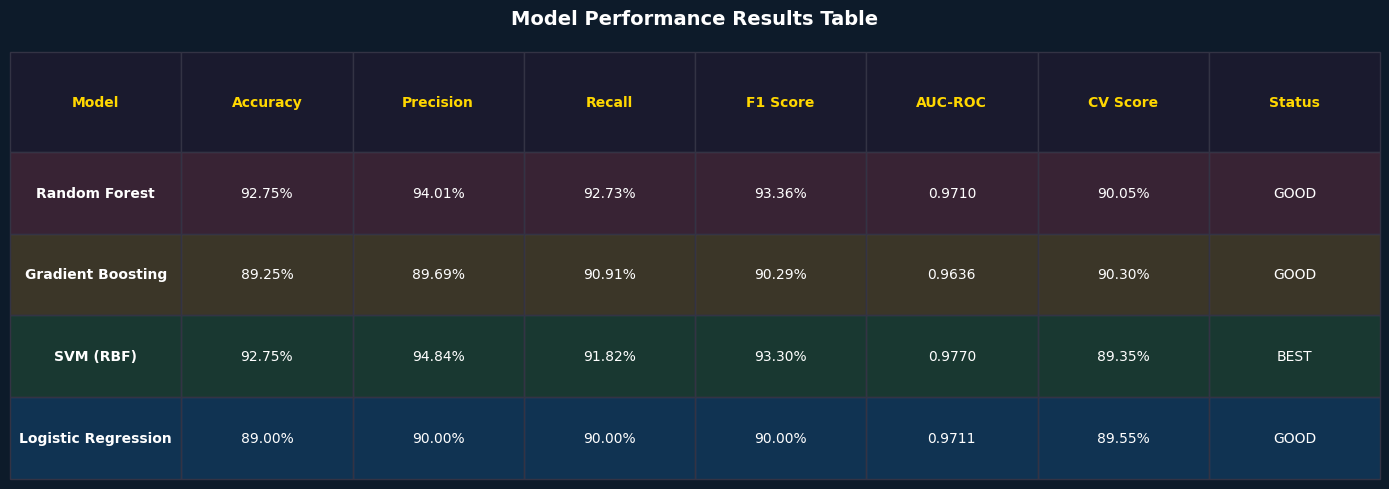

Saved: output_results_table.png


In [8]:
best_name = max(results, key=lambda x: results[x]['auc'])

print("\n" + "="*78)
print(f"{'Model':<25} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8} {'AUC':>8} {'CV':>8}")
print("="*78)
for name, r in results.items():
    marker = " BEST" if name == best_name else ""
    print(f"{name:<25} {r['accuracy']:>9.3f} {r['precision']:>10.3f} {r['recall']:>8.3f} {r['f1']:>8.3f} {r['auc']:>8.3f} {r['cv_score']:>8.3f}{marker}")
print("="*78)

fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor('#0D1B2A'); ax.set_facecolor('#0D1B2A'); ax.axis('off')
hdrs = ['Model','Accuracy','Precision','Recall','F1 Score','AUC-ROC','CV Score','Status']
rows_d = []
for name, r in results.items():
    st = 'BEST' if name == best_name else ('GOOD' if r['accuracy']>=0.85 else 'OK')
    rows_d.append([name,f"{r['accuracy']*100:.2f}%",f"{r['precision']*100:.2f}%",
                   f"{r['recall']*100:.2f}%",f"{r['f1']*100:.2f}%",
                   f"{r['auc']:.4f}",f"{r['cv_score']*100:.2f}%",st])
tbl = ax.table(cellText=rows_d,colLabels=hdrs,cellLoc='center',loc='center',bbox=[0,0,1,1])
tbl.auto_set_font_size(False); tbl.set_fontsize(11)
RC4 = ['#E94560','#F5A623','#4CAF50','#2196F3']
for (row,col),cell in tbl.get_celld().items():
    cell.set_edgecolor('#333344')
    if row==0:
        cell.set_facecolor('#1A1A2E'); cell.set_text_props(color='#FFD700',fontweight='bold',fontsize=10); cell.set_height(0.22)
    else:
        cell.set_facecolor(RC4[(row-1)%4]+'33'); cell.set_text_props(color='white',fontsize=10); cell.set_height(0.18)
        if col==0: cell.set_text_props(color='white',fontweight='bold',fontsize=10)
ax.set_title('Model Performance Results Table', color='white', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('output_results_table.png',dpi=150,bbox_inches='tight',facecolor='#0D1B2A')
plt.show(); print("Saved: output_results_table.png")

## Cell 9 — Process Tree Diagram

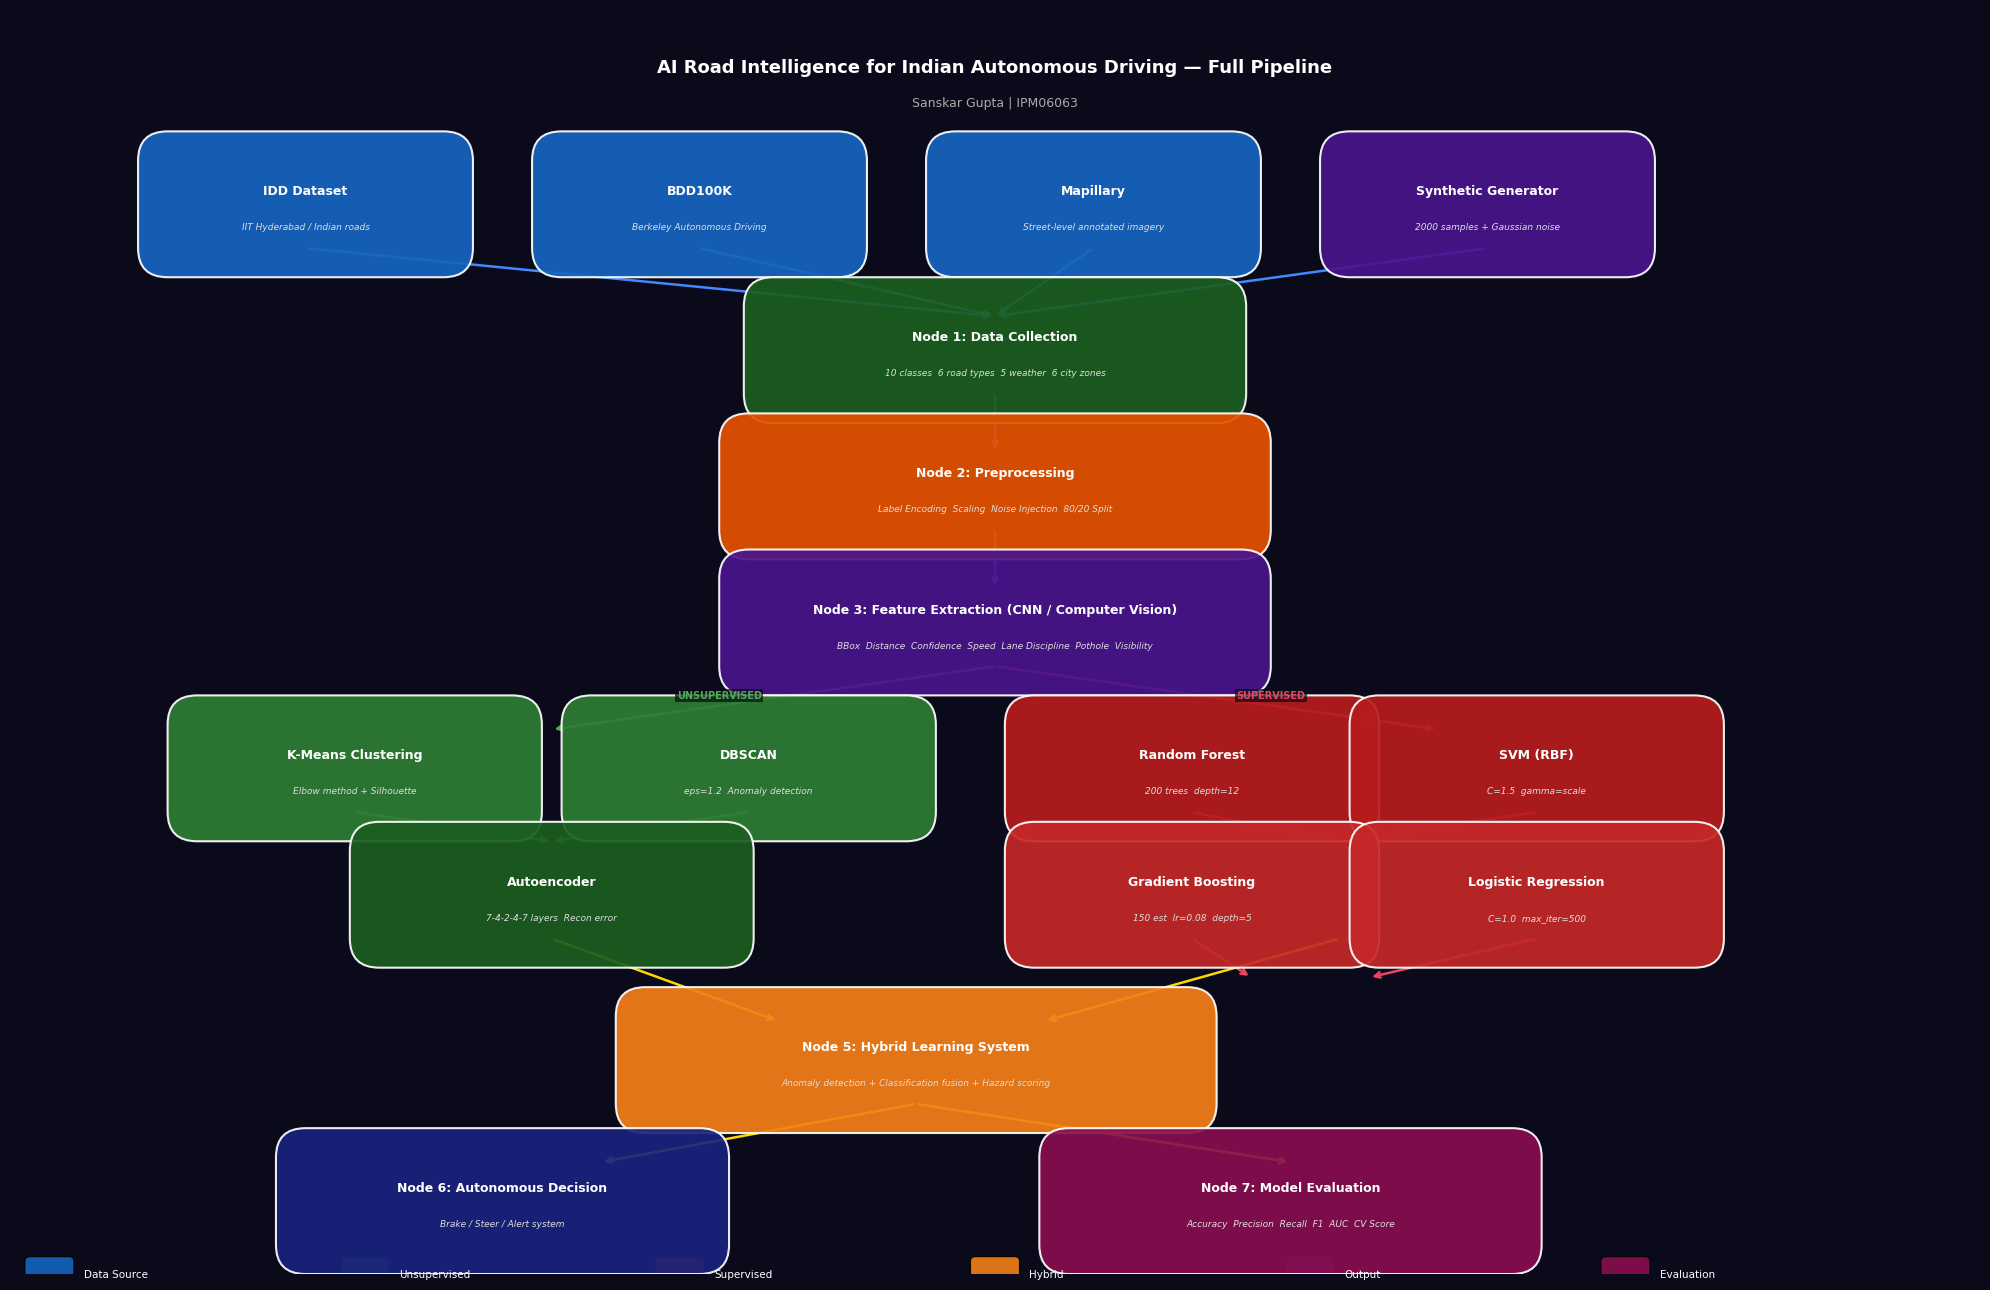

Saved: output_9_process_tree.png


In [9]:
fig, ax = plt.subplots(figsize=(20, 13))
fig.patch.set_facecolor('#0A0A1A'); ax.set_facecolor('#0A0A1A')
ax.set_xlim(0,20); ax.set_ylim(0,13); ax.axis('off')

def node(ax, x, y, w, h, title, subtitle, color):
    ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle="round,pad=0.3",
        facecolor=color,edgecolor='white',linewidth=1.5,alpha=0.92,zorder=3))
    ax.text(x,y+0.13,title,ha='center',va='center',color='white',fontsize=9,fontweight='bold',zorder=4)
    ax.text(x,y-0.24,subtitle,ha='center',va='center',color='#DDD',fontsize=6.5,zorder=4,style='italic')

def arr(ax, x1, y1, x2, y2, col='#4488FF'):
    ax.annotate('',xy=(x2,y2),xytext=(x1,y1),
        arrowprops=dict(arrowstyle='->',color=col,lw=1.8),zorder=2)

def lbl(ax, x, y, t, c='#FFD700'):
    ax.text(x,y,t,ha='center',va='center',color=c,fontsize=7,fontweight='bold',zorder=5,
        bbox=dict(facecolor='#0A0A1A',edgecolor='none',alpha=0.7,pad=1))

ax.text(10,12.4,'AI Road Intelligence for Indian Autonomous Driving — Full Pipeline',
    ha='center',va='center',color='white',fontsize=13,fontweight='bold')
ax.text(10,12.0,'Sanskar Gupta | IPM06063',ha='center',color='#AAA',fontsize=9)

node(ax,3,11,2.8,0.9,'IDD Dataset','IIT Hyderabad / Indian roads','#1565C0')
node(ax,7,11,2.8,0.9,'BDD100K','Berkeley Autonomous Driving','#1565C0')
node(ax,11,11,2.8,0.9,'Mapillary','Street-level annotated imagery','#1565C0')
node(ax,15,11,2.8,0.9,'Synthetic Generator','2000 samples + Gaussian noise','#4A148C')
for sx in [3,7,11,15]: arr(ax,sx,10.55,10,9.85)

node(ax,10,9.5,4.5,0.9,'Node 1: Data Collection','10 classes  6 road types  5 weather  6 city zones','#1B5E20')
arr(ax,10,9.05,10,8.45)
node(ax,10,8.1,5.0,0.9,'Node 2: Preprocessing','Label Encoding  Scaling  Noise Injection  80/20 Split','#E65100')
arr(ax,10,7.65,10,7.05)
node(ax,10,6.7,5.0,0.9,'Node 3: Feature Extraction (CNN / Computer Vision)','BBox  Distance  Confidence  Speed  Lane Discipline  Pothole  Visibility','#4A148C')
arr(ax,10,6.25,5.5,5.6,'#4CAF50'); arr(ax,10,6.25,14.5,5.6,'#E94560')
lbl(ax,7.2,5.95,'UNSUPERVISED','#4CAF50'); lbl(ax,12.8,5.95,'SUPERVISED','#E94560')

node(ax,3.5,5.2,3.2,0.9,'K-Means Clustering','Elbow method + Silhouette','#2E7D32')
node(ax,7.5,5.2,3.2,0.9,'DBSCAN','eps=1.2  Anomaly detection','#2E7D32')
node(ax,5.5,3.9,3.5,0.9,'Autoencoder','7-4-2-4-7 layers  Recon error','#1B5E20')
node(ax,12,5.2,3.2,0.9,'Random Forest','200 trees  depth=12','#B71C1C')
node(ax,15.5,5.2,3.2,0.9,'SVM (RBF)','C=1.5  gamma=scale','#B71C1C')
node(ax,12,3.9,3.2,0.9,'Gradient Boosting','150 est  lr=0.08  depth=5','#C62828')
node(ax,15.5,3.9,3.2,0.9,'Logistic Regression','C=1.0  max_iter=500','#C62828')
for sx in [3.5,7.5]: arr(ax,sx,4.75,5.5,4.45,'#4CAF50')
for sx in [12,15.5]: arr(ax,sx,4.75,13.5,4.45,'#E94560')
arr(ax,15.5,3.45,13.8,3.05,'#E94560'); arr(ax,12,3.45,12.6,3.05,'#E94560')
arr(ax,5.5,3.45,7.8,2.6,'#FFD700'); arr(ax,13.5,3.45,10.5,2.6,'#FFD700')

node(ax,9.2,2.2,5.5,0.9,'Node 5: Hybrid Learning System','Anomaly detection + Classification fusion + Hazard scoring','#F57F17')
arr(ax,9.2,1.75,6,1.15,'#FFD700'); arr(ax,9.2,1.75,13,1.15,'#FFD700')
node(ax,5,0.75,4.0,0.9,'Node 6: Autonomous Decision','Brake / Steer / Alert system','#1A237E')
node(ax,13,0.75,4.5,0.9,'Node 7: Model Evaluation','Accuracy  Precision  Recall  F1  AUC  CV Score','#880E4F')

leg = [('#1565C0','Data Source'),('#1B5E20','Unsupervised'),('#B71C1C','Supervised'),
       ('#F57F17','Hybrid'),('#1A237E','Output'),('#880E4F','Evaluation')]
for i,(c,t) in enumerate(leg):
    bx=0.4+i*3.2
    ax.add_patch(FancyBboxPatch((bx-0.2,-0.15),0.4,0.28,boxstyle="round,pad=0.05",facecolor=c,alpha=0.9))
    ax.text(bx+0.35,-0.01,t,va='center',color='white',fontsize=7.5)

plt.tight_layout()
plt.savefig('output_9_process_tree.png',dpi=150,bbox_inches='tight',facecolor='#0A0A1A')
plt.show(); print("Saved: output_9_process_tree.png")